# [올라운더] 2차 프로젝트
## 데이터 EDA — 피크 경보 모델 & 한전 DR 계산

### 프로젝트 개요
- **데이터**: 2021년 1~9월 제조공장 시간별 전력 사용량 (OKM 증강 데이터)
- **핵심 서비스 1**: 피크 경보 모델 — 전력 사용량이 임계치를 초과할 것을 사전 예측
- **핵심 서비스 2**: 한전 DR (수요반응) — CBL 기반 감축량 및 정산금 자동 산출

### 목차
1. 데이터 기본 정보  
2. 데이터 품질 분석  
3. 전력 사용 시계열 분석  
4. 전력 사용 패턴 (시간대 / 요일 / 히트맵)  
5. 피크 시간대 정의 및 분석  
6. 기상 데이터 상관분석  
7. 생산량 - 전력 관계 분석  
8. 한전 DR (수요반응) 계산  
9. 피처 엔지니어링 방향  
10. 데이터 증강 전략

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 ────────────────────────────────────────
# Windows에 기본 설치된 '맑은 고딕(Malgun Gothic)' 폰트를 직접 경로로 지정합니다.
# 이렇게 하면 matplotlib이 폰트를 못 찾는 문제를 방지할 수 있습니다.
import os
from matplotlib import rcParams
rcParams['font.family'] = 'New Gulim'
rcParams['font.size'] = 10
rcParams['axes.unicode_minus'] = False

In [155]:
# 데이터 로드
df_raw = pd.read_csv('data/okm_augumented_2021.csv', encoding='utf-8-sig')
print(f'원본 데이터 shape: {df_raw.shape}')
df_raw.head(3)

원본 데이터 shape: (6168, 18)


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5


In [156]:
# 기본 전처리
# 시간 이상값(0~23 범위 외) 제거
valid_hours = df_raw['시간'].isin(range(24))
outlier_rows = df_raw[~valid_hours]
print(f'시간 이상값 행 수: {len(outlier_rows)} → 날짜: {outlier_rows["날짜"].unique()}')

df = df_raw[valid_hours].copy()
print(f'이상값 제거 후 shape: {df.shape}')

# datetime 컬럼 생성
df['datetime'] = pd.to_datetime(
    df['날짜'].astype(str) + df['시간'].astype(str).str.zfill(2),
    format='%Y%m%d%H'
)
df = df.sort_values('datetime').reset_index(drop=True)

# 파생 컬럼
day_map = {1: '월', 2: '화', 3: '수', 4: '목', 5: '금', 6: '토', 7: '일'}
df['요일명'] = df['day'].map(day_map)
df['is_weekend'] = df['day'].isin([6, 7]).astype(int)
df['is_workday'] = df['day'].isin([1, 2, 3, 4, 5]).astype(int)

def get_season(m):
    if m in [12, 1, 2]: return '겨울'
    elif m in [3, 4, 5]: return '봄'
    elif m in [6, 7, 8]: return '여름'
    else: return '가을'

df['계절'] = df['m'].apply(get_season)

tariff_map = {109.8: '경부하(겨울)', 167.2: '중간부하', 191.6: '최대부하(여름)'}
df['요금_계절'] = df['전기요금(계절)'].map(tariff_map)

print('전처리 완료')
df.head()

시간 이상값 행 수: 48 → 날짜: [20210713 20210715]
이상값 제거 후 shape: (6120, 18)
전처리 완료


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,...,d,m,공장인원,인건비,datetime,요일명,is_weekend,is_workday,계절,요금_계절
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,...,1,1,0.0,1.5,2021-01-01 00:00:00,금,0,1,겨울,경부하(겨울)
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,...,1,1,0.0,1.5,2021-01-01 01:00:00,금,0,1,겨울,경부하(겨울)
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,...,1,1,0.0,1.5,2021-01-01 02:00:00,금,0,1,겨울,경부하(겨울)
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,...,1,1,0.0,1.5,2021-01-01 03:00:00,금,0,1,겨울,경부하(겨울)
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,...,1,1,0.0,1.5,2021-01-01 04:00:00,금,0,1,겨울,경부하(겨울)


---
## 1. 데이터 기본 정보

In [157]:
print('=' * 60)
print(f'데이터 기간  : {df["datetime"].min()} ~ {df["datetime"].max()}')
print(f'총 행 수     : {len(df):,} (시간 단위)')
print(f'고유 날짜 수 : {df["날짜"].nunique()}일')
print(f'컬럼 수      : {len(df.columns)}')
print('=' * 60)

col_desc = {
    '날짜': 'YYYYMMDD 날짜',
    '시간': '0~23 시각',
    '15분': '15분 전력 (kW)',
    '30분': '30분 전력 (kW)',
    '45분': '45분 전력 (kW)',
    '60분': '60분 전력 (kW)',
    '평균': '시간 평균 전력 (kW) ← 주요 타겟',
    '생산량': '시간당 생산량',
    '기온': '온도 (°C)',
    '풍속': '풍속 (m/s)',
    '습도': '상대습도 (%)',
    '강수량': '강수량 (mm)',
    '전기요금(계절)': '한전 계절별 단가 (원/kWh)',
    'day': '요일 (1=월 ~ 7=일)',
    'd': '일(day of month)',
    'm': '월(month)',
    '공장인원': '근무 인원 수',
    '인건비': '인건비 계수',
}
desc_df = pd.DataFrame([
    {'컬럼': k, '설명': v, '결측': df[k].isnull().sum()}
    for k, v in col_desc.items() if k in df.columns
])
print('\n■ 컬럼 설명')
print(desc_df.to_string(index=False))

print('\n■ 기술통계')
df[['15분','30분','45분','60분','평균','생산량','기온','풍속','습도','강수량']].describe().round(1)

데이터 기간  : 2021-01-01 00:00:00 ~ 2021-09-14 23:00:00
총 행 수     : 6,120 (시간 단위)
고유 날짜 수 : 255일
컬럼 수      : 24

■ 컬럼 설명
      컬럼                    설명  결측
      날짜           YYYYMMDD 날짜   0
      시간               0~23 시각   0
     15분           15분 전력 (kW)   0
     30분           30분 전력 (kW)   0
     45분           45분 전력 (kW)   0
     60분           60분 전력 (kW)   0
      평균 시간 평균 전력 (kW) ← 주요 타겟   0
     생산량               시간당 생산량   0
      기온               온도 (°C)   0
      풍속              풍속 (m/s)   3
      습도              상대습도 (%)   0
     강수량              강수량 (mm)   1
전기요금(계절)     한전 계절별 단가 (원/kWh)   0
     day        요일 (1=월 ~ 7=일)   0
       d       일(day of month)   0
       m              월(month)   0
    공장인원               근무 인원 수  17
     인건비                인건비 계수   0

■ 기술통계


,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량
count,6120.0,6120.0,6120.0,6120.0,6120.0,6120.0,6120.0,6117.0,6120.0,6119.0
mean,90.1,92.3,94.8,94.7,93.1,471.0,15.8,2.1,70.0,2.3
std,55.4,57.9,59.3,59.4,57.4,859.9,9.1,1.2,23.0,9.6
min,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,0.0,8.0,0.0
25%,23.0,23.0,23.0,23.0,23.0,0.0,9.5,1.2,53.0,0.0
50%,101.0,104.0,105.0,107.0,104.0,48.0,17.3,1.9,74.0,0.0
75%,133.0,142.0,148.0,149.0,143.0,650.2,23.2,2.8,91.0,0.1
max,207.0,222.0,218.0,214.0,208.0,9830.0,33.4,7.6,98.0,122.4


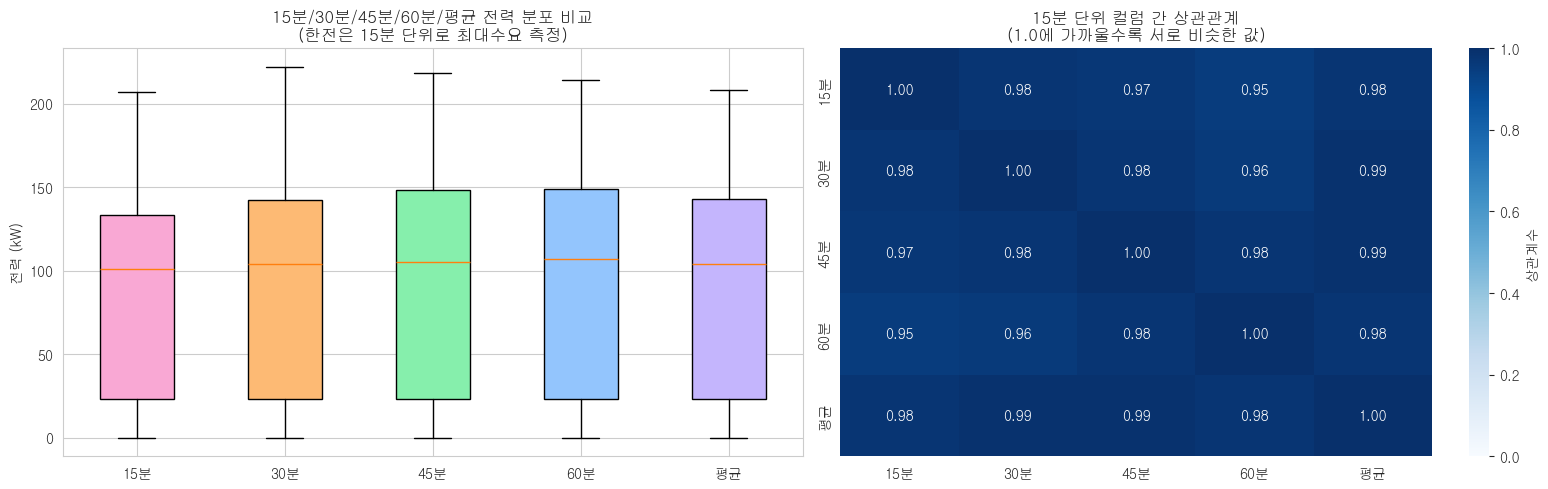

■ 15분 단위 최대값 vs 시간 평균 차이
  평균 차이: 7.3 kW
  최대 차이: 67.0 kW
  차이 10kW 이상인 시간: 1740건

  ※ 차이가 크다면 → 평균 대신 15분 단위 최대값을 피크 판단 기준으로 사용 권장
  ※ 차이가 작다면  → 시간 평균으로도 충분히 피크 감지 가능


In [158]:
# ============================================================
# 15분 단위 전력 데이터 분석
# ------------------------------------------------------------
# 한전은 "최대수요전력"을 15분 단위로 측정합니다.
# 즉, 한 시간 안에서도 15분/30분/45분/60분 각각의 값이 다를 수 있고,
# 이 중 가장 높은 값이 피크 판단 기준이 됩니다.
# → 시간 평균(평균 컬럼)만 보면 실제 순간 피크를 놓칠 수 있습니다!
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── [왼쪽] 15분 단위 4개 값의 분포 비교 ──────────────────────
sub_cols = ['15분', '30분', '45분', '60분', '평균']
sub_data  = [df[c].values for c in sub_cols]

bp = axes[0].boxplot(sub_data, labels=sub_cols, patch_artist=True)
colors_sub = ['#f9a8d4','#fdba74','#86efac','#93c5fd','#c4b5fd']
for patch, color in zip(bp['boxes'], colors_sub):
    patch.set_facecolor(color)

axes[0].set_title('15분/30분/45분/60분/평균 전력 분포 비교\n(한전은 15분 단위로 최대수요 측정)')
axes[0].set_ylabel('전력 (kW)')

# ── [오른쪽] 15분 단위 값들의 상관관계 ────────────────────────
# 4개 값이 서로 얼마나 일치하는지 확인
# → 일치도가 높으면 "평균" 하나만 써도 무방
# → 일치도가 낮으면 각 시간대 값을 개별 피처로 써야 함
corr_sub = df[sub_cols].corr().round(2)
sns.heatmap(corr_sub, ax=axes[1],
            annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1,
            cbar_kws={'label': '상관계수'})
axes[1].set_title('15분 단위 컬럼 간 상관관계\n(1.0에 가까울수록 서로 비슷한 값)')

plt.tight_layout()
plt.show()

# 15분 단위 최대값 vs 평균 차이 분석
df['분기내_최대'] = df[['15분','30분','45분','60분']].max(axis=1)
df['최대_평균_차이'] = df['분기내_최대'] - df['평균']

print('■ 15분 단위 최대값 vs 시간 평균 차이')
print(f'  평균 차이: {df["최대_평균_차이"].mean():.1f} kW')
print(f'  최대 차이: {df["최대_평균_차이"].max():.1f} kW')
print(f'  차이 10kW 이상인 시간: {(df["최대_평균_차이"] >= 10).sum()}건')
print()
print('  ※ 차이가 크다면 → 평균 대신 15분 단위 최대값을 피크 판단 기준으로 사용 권장')
print('  ※ 차이가 작다면  → 시간 평균으로도 충분히 피크 감지 가능')

---
## 2. 데이터 품질 분석

In [159]:
# 결측치
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'결측 수': missing, '결측률(%)': missing_pct})
miss_df = miss_df[miss_df['결측 수'] > 0]
print('■ 결측치 현황')
print(miss_df)

# 중복 행
dup = df.duplicated(subset=['날짜', '시간']).sum()
print(f'\n■ 중복 행 수: {dup}')

# 시계열 연속성
expected = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='H')
missing_ts = set(expected) - set(df['datetime'])
print(f'\n■ 누락된 시간대: {len(missing_ts)}개')
if missing_ts:
    print('  (최대 10개):', sorted(missing_ts)[:10])

■ 결측치 현황
      결측 수  결측률(%)
풍속       3    0.05
강수량      1    0.02
공장인원    17    0.28

■ 중복 행 수: 0

■ 누락된 시간대: 48개
  (최대 10개): [Timestamp('2021-07-13 00:00:00'), Timestamp('2021-07-13 01:00:00'), Timestamp('2021-07-13 02:00:00'), Timestamp('2021-07-13 03:00:00'), Timestamp('2021-07-13 04:00:00'), Timestamp('2021-07-13 05:00:00'), Timestamp('2021-07-13 06:00:00'), Timestamp('2021-07-13 07:00:00'), Timestamp('2021-07-13 08:00:00'), Timestamp('2021-07-13 09:00:00')]


### 📋 데이터 품질 분석 결과 해석 및 처리 방향

---

#### 1. 결측치 처리 방법

| 컬럼 | 결측 수 | 원인 추정 | 처리 방법 |
|------|---------|----------|----------|
| 풍속 | 3개 | 기상 관측 오류 | **보간법(interpolate)** — 앞뒤 값의 중간값으로 채움 |
| 강수량 | 1개 | 비 없는 날 미입력 | **0으로 채우기(fillna(0))** |
| 공장인원 | 17개 | 휴일/공휴일 미입력 | **같은 요일 평균으로 채우기** |

> **보간법이란?**  
> `[1.2, NaN, 1.8]` → `[1.2, 1.5, 1.8]`  
> 앞뒤 값의 중간값을 자동으로 계산해서 빈칸을 채우는 방법입니다.

---

#### 2. 누락된 시간대 (7월 13~14일, 48시간) 처리 방법

이 부분이 가장 중요합니다. 단순히 채우는 것이 아니라 **모델 오염 방지**가 핵심입니다.

**왜 위험한가?**
```
라그 피처(lag) 예시:
  7월 15일 0시의 "24시간 전 전력값(lag24)" 을 구하면
  → 원래는 7월 14일 0시 값이어야 하는데
  → 데이터가 없으니 전혀 다른 날의 값이 들어옴
  → 모델이 잘못된 패턴을 학습하게 됨 ❌
```

**권장 처리 순서:**

```
1단계: 결측치 채우기
   풍속    → interpolate(method='linear')
   강수량  → fillna(0)
   공장인원 → 요일별 평균으로 채우기

2단계: 누락 구간 마킹
   7월 13~14일 이후 라그/롤링 피처가 계산된 행에 NaN 표시
   → 모델 학습 시 해당 행을 제외

3단계: 최종 확인
   df.isnull().sum() 으로 결측 없는지 재확인
```

**처리를 잘 하면:**
- ✅ 라그 피처 오염 방지
- ✅ 모델이 잘못된 패턴 학습 방지
- ✅ 전체 데이터의 연속성 유지

**처리를 안 하면:**
- ❌ 7월 15일 이후 lag24, lag48 피처가 엉뚱한 날 값으로 채워짐
- ❌ 모델 예측 정확도 저하

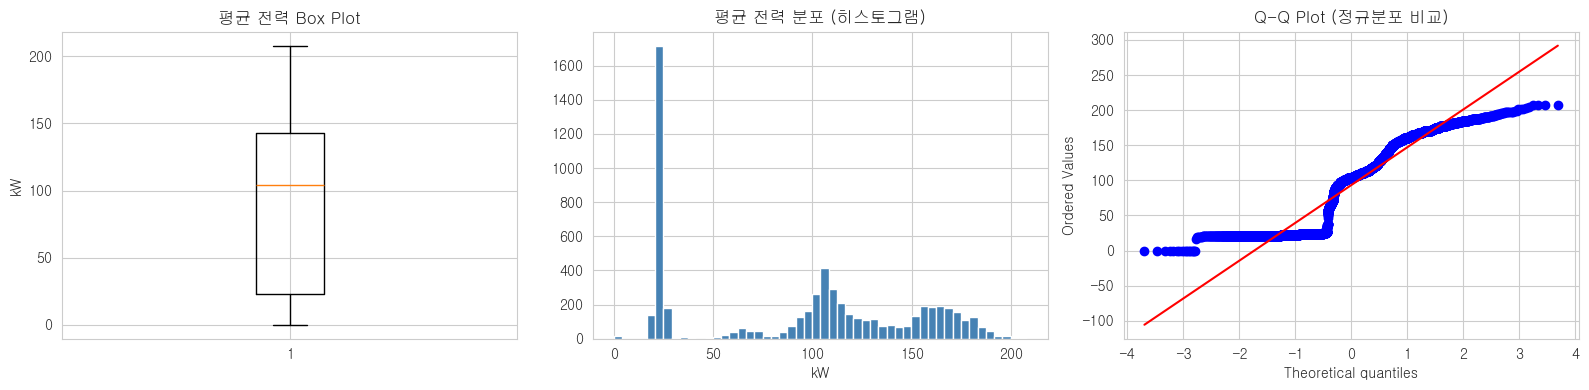

IQR 이상치 범위: [-157.0, 323.0] kW
이상치 행 수  : 0 (0.0%)

■ 전력 분위수 (kW)
    0.10  0.25   0.50   0.75   0.90   0.95   0.99
평균  21.0  23.0  104.0  143.0  169.0  177.0  189.0


In [160]:
# 전력 사용량 이상치 탐지
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].boxplot(df['평균'].dropna())
axes[0].set_title('평균 전력 Box Plot')
axes[0].set_ylabel('kW')

axes[1].hist(df['평균'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('평균 전력 분포 (히스토그램)')
axes[1].set_xlabel('kW')

stats.probplot(df['평균'].dropna(), dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (정규분포 비교)')

plt.tight_layout()
plt.show()

Q1 = df['평균'].quantile(0.25)
Q3 = df['평균'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df['평균'] < lower) | (df['평균'] > upper)]
print(f'IQR 이상치 범위: [{lower:.1f}, {upper:.1f}] kW')
print(f'이상치 행 수  : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
print(f'\n■ 전력 분위수 (kW)')
print(df['평균'].quantile([0.1,0.25,0.5,0.75,0.9,0.95,0.99]).to_frame().T.round(1))

### 📋 이상치 분석 결과 해석

---

#### 핵심만 요약하면

이 공장의 전력은 **두 가지 상태**만 있습니다.

```
😴 꺼져있는 상태  →   0~ 50 kW  (야간, 주말)
🏭 돌아가는 상태  → 100~180 kW  (낮, 평일)
```

---

#### 그래프 3개를 설명

**왼쪽 — 박스플롯**
> "전력값의 절반은 23~143 kW 사이에 있고, 가장 많이 쓴 순간은 208 kW였다"

**가운데 — 히스토그램**
> "공장이 꺼진 시간이 제일 많고 (왼쪽 높은 막대),  
> 가동 중인 시간도 꽤 많다 (오른쪽 덩어리)"

**오른쪽 — Q-Q Plot**
> "전력 데이터가 자연스러운 종 모양이 아니라  
> 두 덩어리로 나뉜 특이한 분포다"

---

#### 이상치 결과

> **수학적으로는 이상한 값이 0개**

이상치가 없는 게 아니라 **IQR 범위가 너무 넓게 잡힌 것**입니다.  
실제로 208 kW 근처의 높은 값들이 우리가 잡아야 할 **피크**입니다.

---

#### 모델 만들 때 시사점

> 공장이 **"켜진 상태"일 때만** 피크가 발생합니다.  
> 야간/주말 (0~50 kW 구간)은 피크 위험이 없습니다.  
> → 모델한테 **"지금 공장이 가동 중인가?"** 를 꼭 알려줘야 합니다.

---
## 3. 전력 사용 시계열 분석

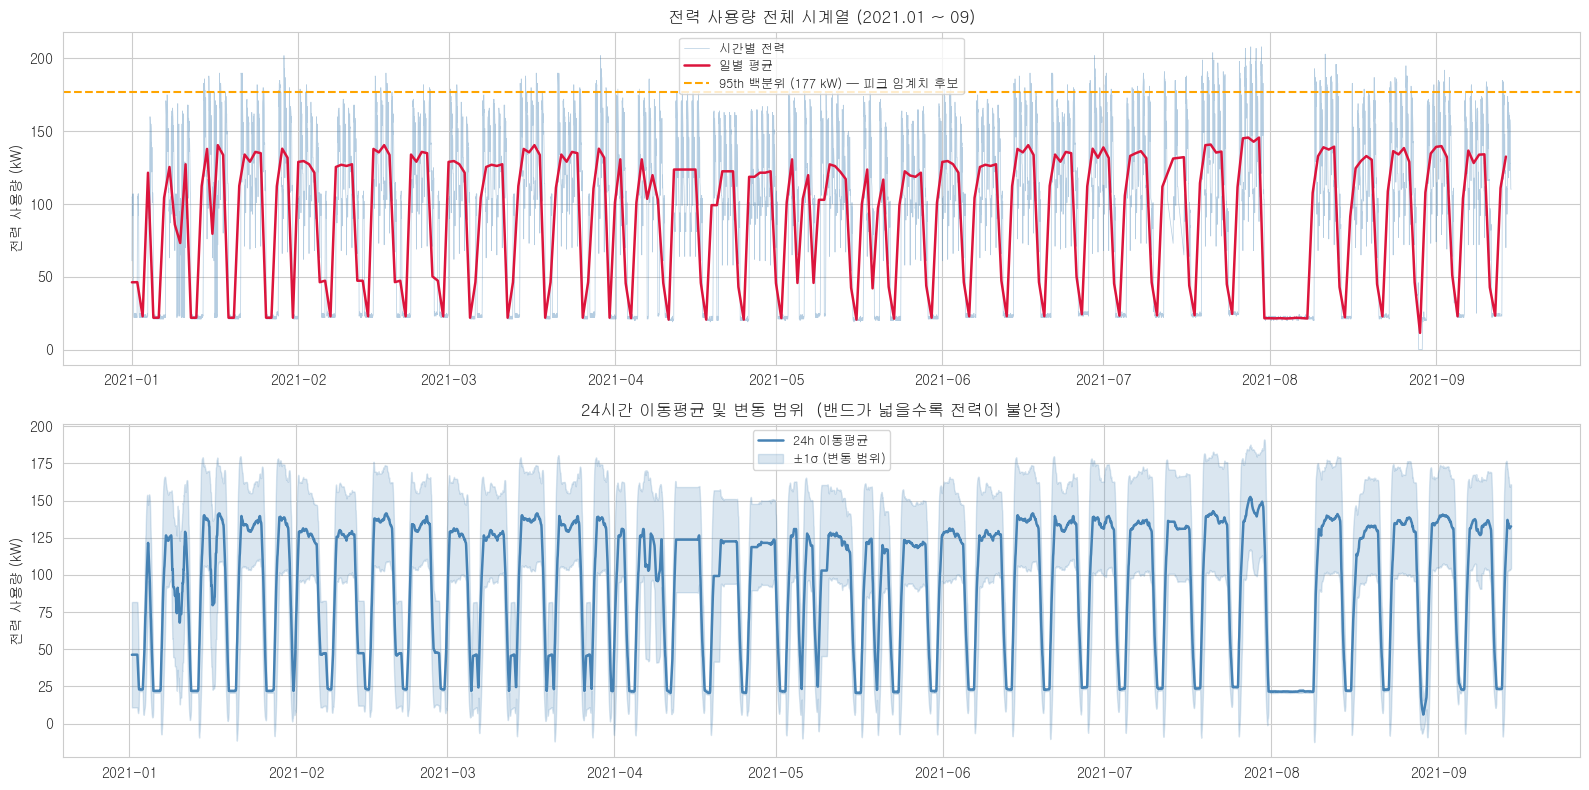

■ 읽는 법
  - 빨간 선이 올라가는 구간  → 평균 전력이 높아지는 시기 (여름철 주목)
  - 주황 점선 위로 튀어나오는 구간 → 피크 발생 구간
  - 아래 그래프 밴드가 넓은 구간  → 전력 변동이 크던 시기


In [161]:
# ============================================================
# 섹션 3. 전력 사용 시계열 분석
# ------------------------------------------------------------
# "시계열(Time Series)"이란?
#   → 시간 순서대로 나열된 데이터입니다.
#   → 전력 데이터처럼 1시간 단위로 측정된 값이 언제 높고 낮은지,
#     어떤 경향(트렌드)이 있는지를 눈으로 확인하는 작업입니다.
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── [위 그래프] 시간별 원본 전력 + 일별 평균 ─────────────────
ax = axes[0]

# 얇은 선: 시간별 원본 데이터 (노이즈가 많아 촘촘하게 보임)
ax.plot(df['datetime'], df['평균'],
        alpha=0.4, linewidth=0.5, color='steelblue', label='시간별 전력')

# 굵은 빨간 선: 하루 단위 평균 → 전체 흐름(트렌드) 파악용
daily_mean  = df.groupby('날짜')['평균'].mean()
daily_dates = pd.to_datetime(daily_mean.index.astype(str), format='%Y%m%d')
ax.plot(daily_dates, daily_mean.values,
        color='crimson', linewidth=1.8, label='일별 평균')

# 주황 점선: 95th 백분위수 = 피크 임계치 후보
# → "전체 시간 중 상위 5%에 해당하는 전력값"을 기준선으로 표시
peak_thr = df['평균'].quantile(0.95)
ax.axhline(peak_thr, color='orange', linestyle='--', linewidth=1.5,
           label=f'95th 백분위 ({peak_thr:.0f} kW) — 피크 임계치 후보')

ax.set_title('전력 사용량 전체 시계열 (2021.01 ~ 09)')
ax.set_ylabel('전력 사용량 (kW)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# ── [아래 그래프] 24시간 이동평균 + 표준편차 밴드 ─────────────
# "이동평균(Rolling Mean)"이란?
#   → 현재 시점 기준 최근 24시간의 평균을 구하는 방법
#   → 단기 노이즈를 줄이고 전체 흐름을 부드럽게 보여줍니다
# "표준편차 밴드"란?
#   → 평균 ± 1σ 구간 = 전력이 얼마나 불안정하게 변동하는지 표현
#   → 밴드가 넓을수록 그 시기에 전력이 크게 요동쳤다는 뜻
ax2 = axes[1]
df_s      = df.set_index('datetime').sort_index()
roll_mean = df_s['평균'].rolling(window=24, center=True).mean()
roll_std  = df_s['평균'].rolling(window=24, center=True).std()

ax2.plot(roll_mean.index, roll_mean,
         color='steelblue', linewidth=1.8, label='24h 이동평균')
ax2.fill_between(roll_mean.index,
                 roll_mean - roll_std,
                 roll_mean + roll_std,
                 alpha=0.2, color='steelblue', label='±1σ (변동 범위)')

ax2.set_title('24시간 이동평균 및 변동 범위  (밴드가 넓을수록 전력이 불안정)')
ax2.set_ylabel('전력 사용량 (kW)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

print('■ 읽는 법')
print('  - 빨간 선이 올라가는 구간  → 평균 전력이 높아지는 시기 (여름철 주목)')
print('  - 주황 점선 위로 튀어나오는 구간 → 피크 발생 구간')
print('  - 아래 그래프 밴드가 넓은 구간  → 전력 변동이 크던 시기')

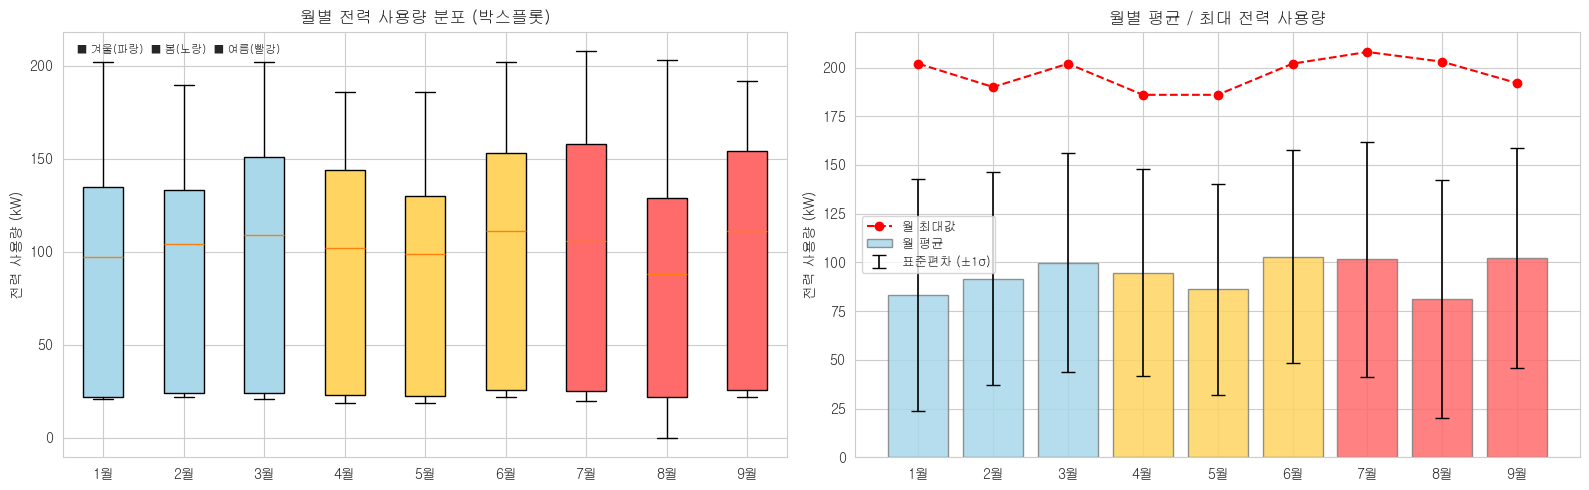

■ 월별 통계 (kW)
       평균  표준편차   최대
1월   83.3  59.6  202
2월   91.6  54.6  190
3월   99.9  56.2  202
4월   94.7  53.1  186
5월   86.1  54.2  186
6월  103.0  54.8  202
7월  101.5  60.3  208
8월   81.2  61.3  203
9월  102.3  56.5  192

■ 읽는 법
  - 박스가 위로 올라갈수록  → 그 달의 전력이 전반적으로 높음
  - 에러바가 길수록         → 전력 변동이 커서 예측이 어려운 달
  - 빨간 점선(최대값)이 높은 달 → 피크 발생 위험이 큰 달


In [162]:
# ============================================================
# 월별 전력 분포 분석
# ------------------------------------------------------------
# 왜 월별로 보나요?
#   → 계절에 따라 전력 사용 패턴이 크게 달라집니다.
#   → 여름(냉방)·겨울(난방) 때 전력이 급증하는 경향이 있고,
#     이를 확인해야 피크 예측 모델에서 "계절"을 중요 피처로 쓸 수 있습니다.
#
# 박스플롯(Box Plot)이란?
#   → 데이터 분포를 박스 형태로 요약한 그래프
#   → 박스 안쪽 선 = 중앙값, 박스 위아래 경계 = 25~75% 구간
#   → 박스 밖의 선/점 = 이상치(극단값)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_labels = ['1월','2월','3월','4월','5월','6월','7월','8월','9월']

# 계절별 색상 (겨울=파랑, 봄=노랑, 여름=빨강)
colors = ['#a8d8ea','#a8d8ea','#a8d8ea',
          '#ffd460','#ffd460','#ffd460',
          '#ff6b6b','#ff6b6b','#ff6b6b']

# ── [왼쪽] 월별 박스플롯 ──────────────────────────────────────
monthly_data = [df[df['m'] == m]['평균'].values for m in range(1, 10)]
bp = axes[0].boxplot(monthly_data, labels=month_labels, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[0].set_title('월별 전력 사용량 분포 (박스플롯)')
axes[0].set_ylabel('전력 사용량 (kW)')
axes[0].text(0.02, 0.97,
             '■ 겨울(파랑)  ■ 봄(노랑)  ■ 여름(빨강)',
             transform=axes[0].transAxes, fontsize=8, va='top')

# ── [오른쪽] 월별 평균 막대 + 표준편차 에러바 + 최대값 선 ───────
# 에러바(오차막대)란?
#   → 막대 위의 T자 선 = 표준편차 (데이터가 평균에서 얼마나 흩어져 있는지)
#   → 에러바가 클수록 해당 월에 전력이 불규칙하게 변했다는 뜻
monthly_stats = df.groupby('m')['평균'].agg(['mean','std','max']).round(1)
monthly_stats.index = month_labels

axes[1].bar(month_labels, monthly_stats['mean'],
            color=colors, edgecolor='gray', alpha=0.85, label='월 평균')
axes[1].errorbar(month_labels, monthly_stats['mean'],
                 yerr=monthly_stats['std'],
                 fmt='none', color='black', capsize=5, linewidth=1.2,
                 label='표준편차 (±1σ)')
axes[1].plot(month_labels, monthly_stats['max'],
             'r--o', markersize=6, linewidth=1.5, label='월 최대값')

axes[1].set_title('월별 평균 / 최대 전력 사용량')
axes[1].set_ylabel('전력 사용량 (kW)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('■ 월별 통계 (kW)')
print(monthly_stats.rename(columns={'mean':'평균','std':'표준편차','max':'최대'}).to_string())
print()
print('■ 읽는 법')
print('  - 박스가 위로 올라갈수록  → 그 달의 전력이 전반적으로 높음')
print('  - 에러바가 길수록         → 전력 변동이 커서 예측이 어려운 달')
print('  - 빨간 점선(최대값)이 높은 달 → 피크 발생 위험이 큰 달')

---
## 4. 전력 사용 패턴 분석 (시간대 / 요일 / 히트맵)

> 피크 경보 모델에서 **"몇 시에, 어느 요일에"** 전력이 높은지 아는 것이 핵심입니다.  
> 이 섹션에서는 시간대·요일별 패턴과 히트맵으로 한눈에 파악합니다.

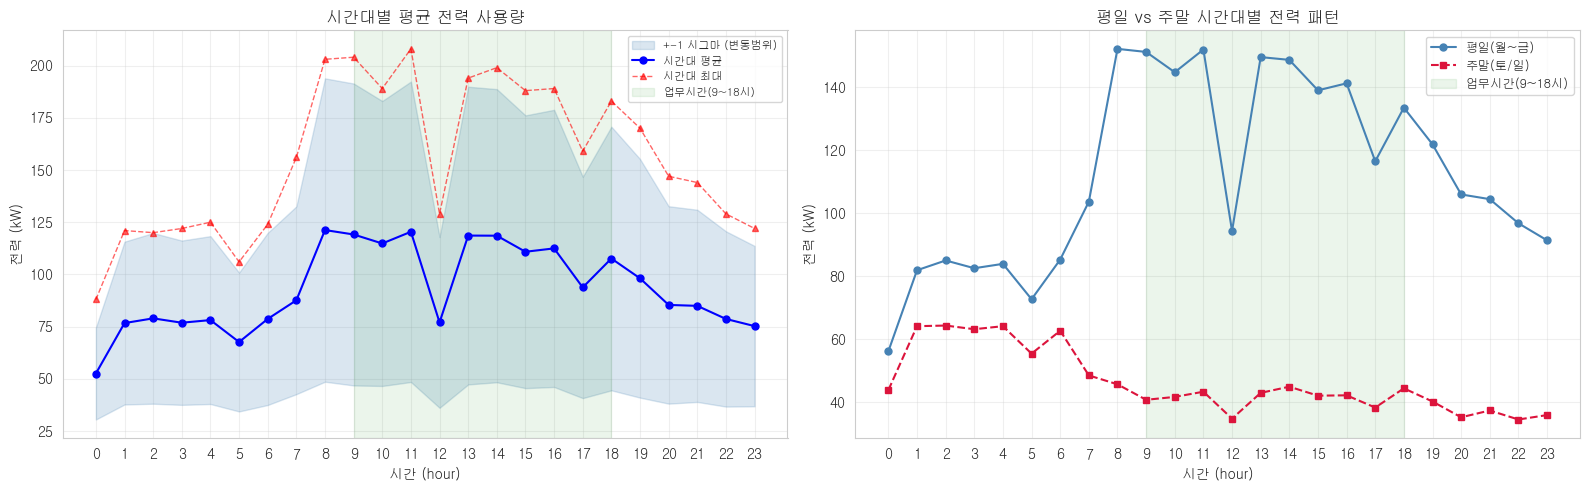

결과 해석
  - 음영이 넓은 시간대  -> 날마다 전력 편차가 큰 시간 (예측 난이도 높음)
  - 평일/주말 차이 큰 구간 -> 생산활동이 평일에 집중됨을 의미
  - 초록 구간 내 전력 급증 시간 -> 피크 집중 구간


In [163]:
# ============================================================
# 시간대별 전력 패턴
# ------------------------------------------------------------
# 왜 시간대별로 보나요?
#   - 공장은 출근(오전)~퇴근(저녁) 사이에 전력이 집중됩니다.
#   - 어느 시간대에 전력이 높아지는지 알면,
#     피크 경보를 그 시간대에 집중 감시하도록 설계할 수 있습니다.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# groupby: 같은 시간(0시, 1시...)끼리 묶어 평균/표준편차/최대값 계산
hourly_avg = df.groupby('시간')['평균'].agg(['mean', 'std', 'max'])

# ── [왼쪽] 전체 시간대별 평균 ─────────────────────────────────
ax = axes[0]
ax.fill_between(hourly_avg.index,
                hourly_avg['mean'] - hourly_avg['std'],
                hourly_avg['mean'] + hourly_avg['std'],
                alpha=0.2, color='steelblue', label='+-1 시그마 (변동범위)')
ax.plot(hourly_avg.index, hourly_avg['mean'],
        'bo-', markersize=5, linewidth=1.5, label='시간대 평균')
ax.plot(hourly_avg.index, hourly_avg['max'],
        'r--^', markersize=4, alpha=0.6, linewidth=1, label='시간대 최대')
ax.axvspan(9, 18, alpha=0.08, color='green', label='업무시간(9~18시)')
ax.set_title('시간대별 평균 전력 사용량')
ax.set_xlabel('시간 (hour)')
ax.set_ylabel('전력 (kW)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── [오른쪽] 평일 vs 주말 비교 ────────────────────────────────
# 평일과 주말의 패턴을 겹쳐 보면:
# - 차이가 크면 = 평일에 생산 집중
# - 차이가 작으면 = 주말에도 조업 있음
ax2 = axes[1]
for is_work, label, color, style in [
    (1, '평일(월~금)', 'steelblue', 'o-'),
    (0, '주말(토/일)', 'crimson',   's--')
]:
    sub = df[df['is_workday'] == is_work].groupby('시간')['평균'].mean()
    ax2.plot(sub.index, sub.values, style,
             markersize=5, linewidth=1.5, label=label, color=color)

ax2.axvspan(9, 18, alpha=0.08, color='green', label='업무시간(9~18시)')
ax2.set_title('평일 vs 주말 시간대별 전력 패턴')
ax2.set_xlabel('시간 (hour)')
ax2.set_ylabel('전력 (kW)')
ax2.set_xticks(range(0, 24))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('결과 해석')
print('  - 음영이 넓은 시간대  -> 날마다 전력 편차가 큰 시간 (예측 난이도 높음)')
print('  - 평일/주말 차이 큰 구간 -> 생산활동이 평일에 집중됨을 의미')
print('  - 초록 구간 내 전력 급증 시간 -> 피크 집중 구간')

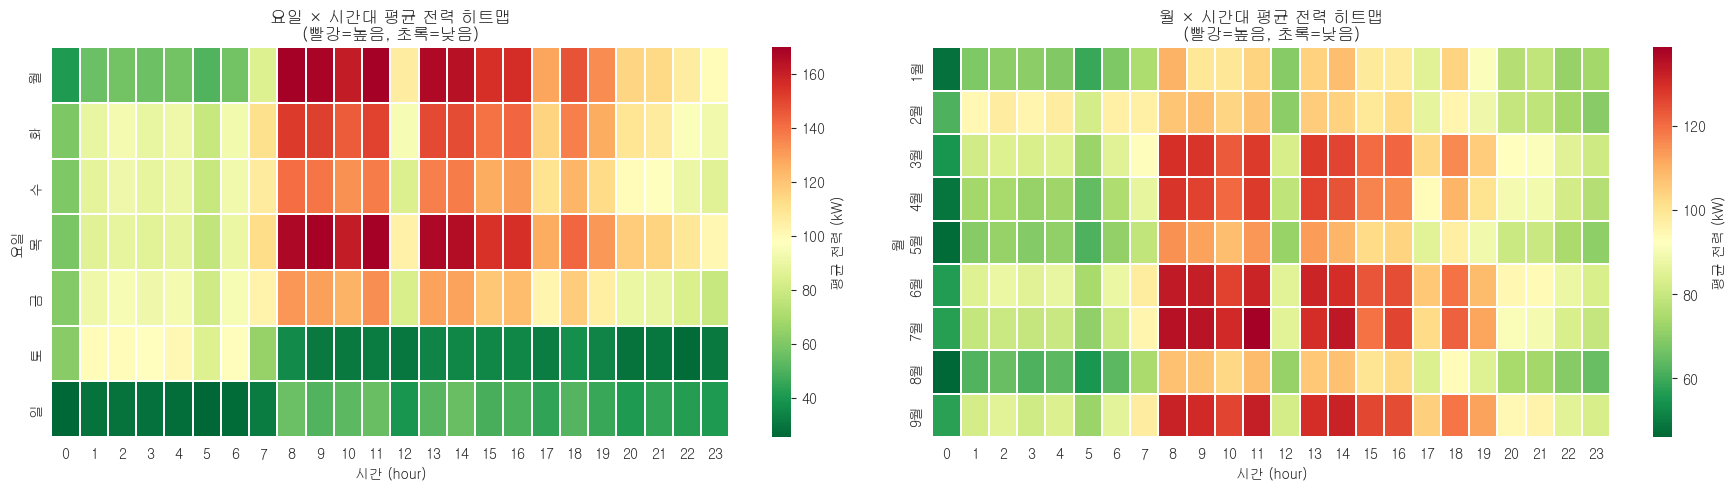

■ 읽는 법
  - 요일 히트맵: 평일(월~금) 낮 시간대(9~18시)가 진한 빨강이면
    → 업무 시간에 생산이 집중되고, 피크도 그 시간대에 몰림
  - 월 히트맵: 특정 월의 특정 시간대가 유독 진하면
    → 그 달 그 시간대가 피크 고위험 구간
  - 주말(토·일)이 평일 대비 옅으면 → 주말 조업 거의 없음


In [164]:
# ============================================================
# 히트맵 (Heatmap) 분석
# ------------------------------------------------------------
# "히트맵"이란?
#   → 행·열 두 가지 기준으로 값을 색으로 표현한 표입니다.
#   → 색이 진할수록(빨강) 전력이 높고, 옅을수록(초록) 낮습니다.
#   → 요일 × 시간 히트맵을 보면
#     "화요일 오후 2시가 가장 위험하다" 같은 인사이트를 바로 얻을 수 있습니다.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── [왼쪽] 요일 × 시간대 히트맵 ──────────────────────────────
# pivot_table: 요일(행) × 시간(열) 형태로 평균 전력을 재구성
pivot_week = df.groupby(['day', '시간'])['평균'].mean().unstack()
pivot_week.index = ['월', '화', '수', '목', '금', '토', '일']

sns.heatmap(pivot_week, ax=axes[0],
            cmap='RdYlGn_r',   # 빨강=높음, 초록=낮음
            annot=False,
            cbar_kws={'label': '평균 전력 (kW)'},
            linewidths=0.3, linecolor='white')
axes[0].set_title('요일 × 시간대 평균 전력 히트맵\n(빨강=높음, 초록=낮음)')
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('요일')

# ── [오른쪽] 월 × 시간대 히트맵 ──────────────────────────────
# 월별로 어느 시간대에 전력이 집중되는지 확인
pivot_month = df.groupby(['m', '시간'])['평균'].mean().unstack()
pivot_month.index = [f'{i}월' for i in pivot_month.index]

sns.heatmap(pivot_month, ax=axes[1],
            cmap='RdYlGn_r',
            annot=False,
            cbar_kws={'label': '평균 전력 (kW)'},
            linewidths=0.3, linecolor='white')
axes[1].set_title('월 × 시간대 평균 전력 히트맵\n(빨강=높음, 초록=낮음)')
axes[1].set_xlabel('시간 (hour)')
axes[1].set_ylabel('월')

plt.tight_layout()
plt.show()

print('■ 읽는 법')
print('  - 요일 히트맵: 평일(월~금) 낮 시간대(9~18시)가 진한 빨강이면')
print('    → 업무 시간에 생산이 집중되고, 피크도 그 시간대에 몰림')
print('  - 월 히트맵: 특정 월의 특정 시간대가 유독 진하면')
print('    → 그 달 그 시간대가 피크 고위험 구간')
print('  - 주말(토·일)이 평일 대비 옅으면 → 주말 조업 거의 없음')

---
## 5. 피크 시간대 정의 및 분석

> **피크(Peak)** 란 전력 사용량이 특정 임계치를 초과하는 순간입니다.  
> 한전은 월별 최대수요전력 기준으로 요금을 부과하기 때문에,  
> 피크를 사전에 감지하고 줄이는 것이 전기요금 절감의 핵심입니다.

In [165]:
# ============================================================
# 피크 임계치 정의
# ------------------------------------------------------------
# "임계치(Threshold)"란?
#   - 이 값을 넘으면 "피크"로 판단하는 기준선입니다.
#   - 너무 낮게 잡으면 경보가 너무 자주 울리고,
#     너무 높게 잡으면 위험한 피크를 놓칩니다.
#   - 보통 95th 백분위수(상위 5%) 또는 계약전력의 특정 비율을 사용합니다.
#
# "백분위수(Percentile)"란?
#   - 전체 데이터를 줄 세웠을 때 몇 번째에 해당하는 값인지 나타냅니다.
#   - 95th = 상위 5%에 해당하는 값 = 전체 시간 중 5%만 이 값을 넘김
# ============================================================

peak_90 = df['평균'].quantile(0.90)
peak_95 = df['평균'].quantile(0.95)
peak_99 = df['평균'].quantile(0.99)

print('■ 피크 임계치 후보')
print(f'  90th 백분위 (상위 10%): {peak_90:.1f} kW')
print(f'  95th 백분위 (상위  5%): {peak_95:.1f} kW  ← 이 프로젝트 기준으로 사용')
print(f'  99th 백분위 (상위  1%): {peak_99:.1f} kW')

# 피크 라벨 생성 (95th 기준)
# is_peak = 1 이면 피크, 0 이면 정상
PEAK_THR = peak_95
df['is_peak'] = (df['평균'] >= PEAK_THR).astype(int)

n_peak    = df['is_peak'].sum()
n_total   = len(df)
print(f'\n■ is_peak 기준값: {PEAK_THR:.1f} kW')
print(f'  피크 발생 횟수: {n_peak}시간 / 전체 {n_total}시간')
print(f'  피크 비율     : {n_peak/n_total*100:.1f}%')
print(f'  비피크 비율   : {(1 - n_peak/n_total)*100:.1f}%')
print()
print('  ※ 피크가 약 5%라는 것은 나머지 95%가 정상이라는 뜻입니다.')
print('    → 피크/비피크 비율이 1:19 로 극심한 불균형 → 데이터 증강 필요')

■ 피크 임계치 후보
  90th 백분위 (상위 10%): 169.0 kW
  95th 백분위 (상위  5%): 177.0 kW  ← 이 프로젝트 기준으로 사용
  99th 백분위 (상위  1%): 189.0 kW

■ is_peak 기준값: 177.0 kW
  피크 발생 횟수: 343시간 / 전체 6120시간
  피크 비율     : 5.6%
  비피크 비율   : 94.4%

  ※ 피크가 약 5%라는 것은 나머지 95%가 정상이라는 뜻입니다.
    → 피크/비피크 비율이 1:19 로 극심한 불균형 → 데이터 증강 필요


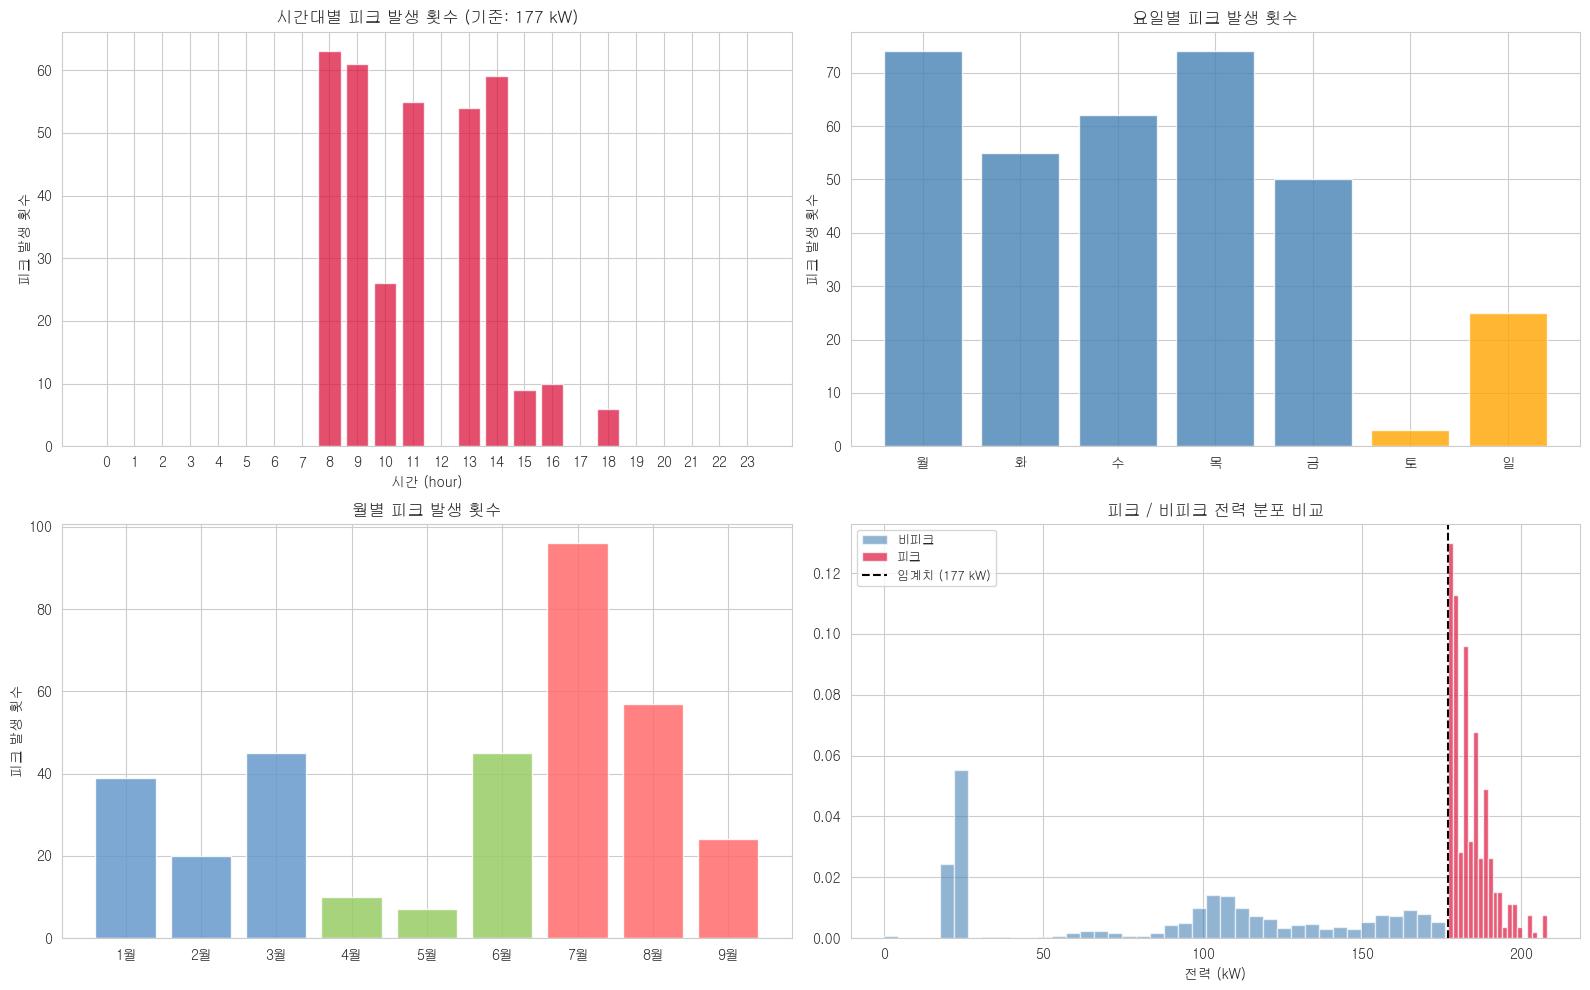

■ 핵심 인사이트
  피크가 가장 많이 발생하는 시간대: 8시
  피크가 가장 많이 발생하는 요일  : 월요일
  피크가 가장 많이 발생하는 월    : 7월


In [166]:
# ============================================================
# 피크 발생 패턴 시각화
# ------------------------------------------------------------
# 피크가 언제 주로 발생하는지 알아야
# 모델이 "어떤 조건에서 피크가 뜨는가"를 학습할 수 있습니다.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── [좌상] 시간대별 피크 발생 횟수 ────────────────────────────
peak_by_hour = df.groupby('시간')['is_peak'].sum()
axes[0,0].bar(peak_by_hour.index, peak_by_hour.values,
              color='crimson', alpha=0.75)
axes[0,0].set_title(f'시간대별 피크 발생 횟수 (기준: {PEAK_THR:.0f} kW)')
axes[0,0].set_xlabel('시간 (hour)')
axes[0,0].set_ylabel('피크 발생 횟수')
axes[0,0].set_xticks(range(0, 24))

# ── [우상] 요일별 피크 발생 횟수 ──────────────────────────────
peak_by_day = (df.groupby('요일명')['is_peak']
                 .sum()
                 .reindex(['월','화','수','목','금','토','일']))
bar_colors  = ['steelblue']*5 + ['orange']*2  # 평일=파랑, 주말=주황
axes[0,1].bar(peak_by_day.index, peak_by_day.values,
              color=bar_colors, alpha=0.8)
axes[0,1].set_title('요일별 피크 발생 횟수')
axes[0,1].set_ylabel('피크 발생 횟수')

# ── [좌하] 월별 피크 발생 횟수 ────────────────────────────────
peak_by_month = df.groupby('m')['is_peak'].sum()
month_colors  = ['#6699cc']*3 + ['#99cc66']*3 + ['#ff6b6b']*3
axes[1,0].bar([f'{i}월' for i in peak_by_month.index],
              peak_by_month.values,
              color=month_colors, alpha=0.85)
axes[1,0].set_title('월별 피크 발생 횟수')
axes[1,0].set_ylabel('피크 발생 횟수')

# ── [우하] 피크 vs 비피크 전력 분포 비교 ───────────────────────
# 두 분포가 명확히 분리될수록 모델이 구분하기 쉬움
df[df['is_peak']==0]['평균'].hist(ax=axes[1,1], bins=40,
    alpha=0.6, color='steelblue', label='비피크', density=True)
df[df['is_peak']==1]['평균'].hist(ax=axes[1,1], bins=20,
    alpha=0.7, color='crimson',   label='피크',   density=True)
axes[1,1].axvline(PEAK_THR, color='black', linestyle='--',
                  linewidth=1.5, label=f'임계치 ({PEAK_THR:.0f} kW)')
axes[1,1].set_title('피크 / 비피크 전력 분포 비교')
axes[1,1].set_xlabel('전력 (kW)')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('■ 핵심 인사이트')
print(f'  피크가 가장 많이 발생하는 시간대: {peak_by_hour.idxmax()}시')
print(f'  피크가 가장 많이 발생하는 요일  : {peak_by_day.idxmax()}요일')
print(f'  피크가 가장 많이 발생하는 월    : {peak_by_month.idxmax()}월')

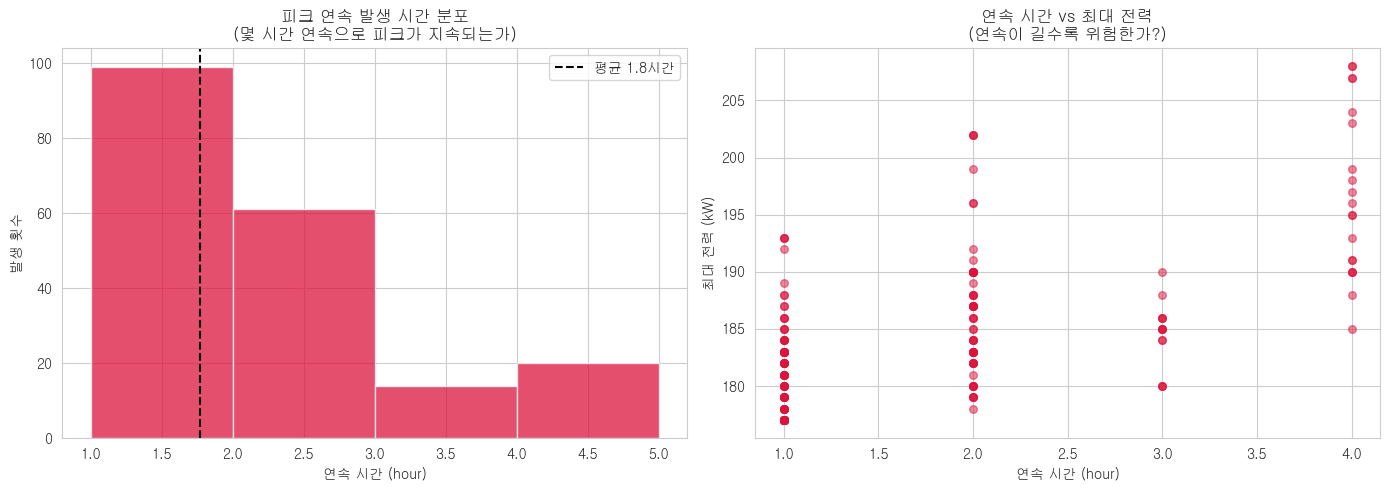

■ 연속 피크 구간 총 194개
  평균 연속 시간: 1.8 시간
  최장 연속 시간: 4 시간
  1시간 단발 피크: 99건 (51%)

  ※ 평균 연속 시간이 길수록 → 피크 경보를 더 앞서서 발령해야 함
  ※ 1시간 단발 피크가 많으면 → 순간 부하 스파이크 원인 분석 필요


In [167]:
# ============================================================
# 연속 피크 구간 분석
# ------------------------------------------------------------
# 피크가 단발성인지, 아니면 여러 시간 연속으로 발생하는지 파악합니다.
# → 연속 피크가 길수록 경보 모델이 얼마나 앞서 알려야 하는지 결정됩니다.
# → 예: 평균 3시간 연속이면, 최소 1~2시간 전에 예측해야 유용합니다.
# ============================================================

df_s = df.sort_values('datetime').copy()

# 피크 그룹 번호 부여: 피크 상태가 바뀌는 시점마다 새 그룹 번호
# (0→1 또는 1→0 으로 바뀔 때마다 cumsum으로 카운트)
df_s['peak_group'] = (df_s['is_peak'] != df_s['is_peak'].shift()).cumsum()

# 피크(is_peak=1)인 구간만 추려서 그룹별 집계
peak_blocks = (df_s[df_s['is_peak'] == 1]
               .groupby('peak_group')
               .agg(
                   시작시간=('datetime', 'first'),
                   종료시간=('datetime', 'last'),
                   연속시간=('is_peak', 'count'),
                   평균전력=('평균', 'mean'),
                   최대전력=('평균', 'max')
               )
               .reset_index(drop=True))

peak_blocks['평균전력'] = peak_blocks['평균전력'].round(1)
peak_blocks['최대전력'] = peak_blocks['최대전력'].round(1)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연속 시간 분포
axes[0].hist(peak_blocks['연속시간'], bins=range(1, peak_blocks['연속시간'].max()+2),
             color='crimson', alpha=0.75, edgecolor='white')
axes[0].axvline(peak_blocks['연속시간'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'평균 {peak_blocks["연속시간"].mean():.1f}시간')
axes[0].set_title('피크 연속 발생 시간 분포\n(몇 시간 연속으로 피크가 지속되는가)')
axes[0].set_xlabel('연속 시간 (hour)')
axes[0].set_ylabel('발생 횟수')
axes[0].legend()

# 연속 시간 vs 최대 전력
axes[1].scatter(peak_blocks['연속시간'], peak_blocks['최대전력'],
                alpha=0.5, color='crimson', s=30)
axes[1].set_title('연속 시간 vs 최대 전력\n(연속이 길수록 위험한가?)')
axes[1].set_xlabel('연속 시간 (hour)')
axes[1].set_ylabel('최대 전력 (kW)')

plt.tight_layout()
plt.show()

print(f'■ 연속 피크 구간 총 {len(peak_blocks)}개')
print(f'  평균 연속 시간: {peak_blocks["연속시간"].mean():.1f} 시간')
print(f'  최장 연속 시간: {peak_blocks["연속시간"].max()} 시간')
print(f'  1시간 단발 피크: {(peak_blocks["연속시간"]==1).sum()}건 ({(peak_blocks["연속시간"]==1).mean()*100:.0f}%)')
print()
print('  ※ 평균 연속 시간이 길수록 → 피크 경보를 더 앞서서 발령해야 함')
print('  ※ 1시간 단발 피크가 많으면 → 순간 부하 스파이크 원인 분석 필요')

---
## 6. 기상 데이터 상관분석

> 기온·습도·풍속 같은 기상 데이터가 전력 사용량에 얼마나 영향을 주는지 확인합니다.  
> 기상 피처가 중요하다면 → 피크 예측 모델의 주요 입력값으로 사용합니다.

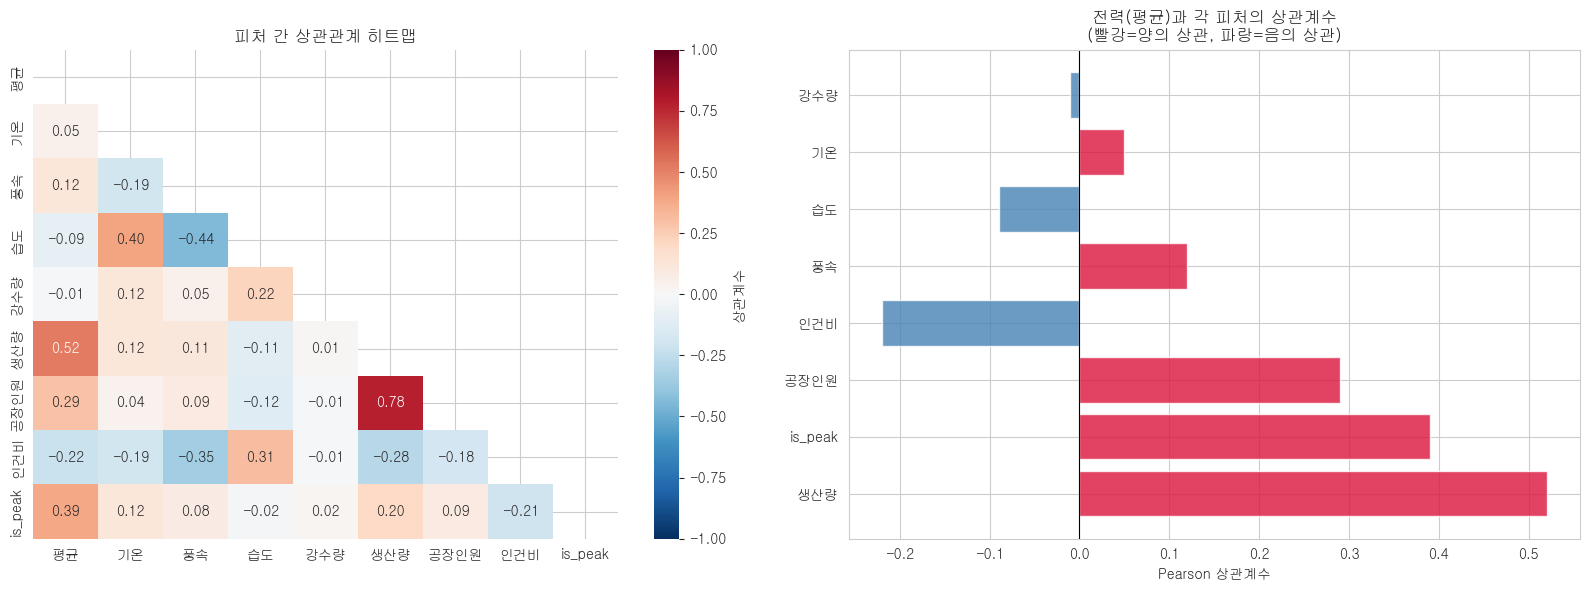

■ 전력과 관련 있는 피처 요약
  생산량     : +0.520  (강함) → 올라가면 전력도 올라감
  is_peak : +0.390  (중간) → 올라가면 전력도 올라감
  공장인원    : +0.290  (중간) → 올라가면 전력도 올라감
  인건비     : -0.220  (중간) → 올라가면 전력은 내려감
  풍속      : +0.120  (약함) → 올라가면 전력도 올라감
  습도      : -0.090  (약함) → 올라가면 전력은 내려감


In [168]:
# ============================================================
# 피처 간 상관관계 분석
# ------------------------------------------------------------
# "상관관계(Correlation)"란?
#   - 두 변수가 함께 움직이는 정도를 -1 ~ +1 사이 숫자로 표현합니다.
#   - +1에 가까울수록 = 한쪽이 올라가면 다른쪽도 올라감 (양의 상관)
#   - -1에 가까울수록 = 한쪽이 올라가면 다른쪽은 내려감 (음의 상관)
#   -  0에 가까울수록 = 별로 관계없음
#
# 히트맵으로 한눈에 어떤 피처가 전력과 관련 있는지 파악합니다.
# ============================================================

corr_cols = ['평균', '기온', '풍속', '습도', '강수량',
             '생산량', '공장인원', '인건비', 'is_peak']
corr_df = df[corr_cols].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── [왼쪽] 상관관계 히트맵 ────────────────────────────────────
# 삼각형 마스크: 대각선 기준 위쪽을 가려서 중복 제거
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, ax=axes[0],
            annot=True, fmt='.2f',   # annot=True: 각 칸에 숫자 표시
            cmap='RdBu_r',           # 빨강=양의 상관, 파랑=음의 상관
            center=0, vmin=-1, vmax=1,
            mask=mask,
            cbar_kws={'label': '상관계수'})
axes[0].set_title('피처 간 상관관계 히트맵')

# ── [오른쪽] 전력(평균)과 각 피처의 상관계수 막대그래프 ─────────
# 어떤 피처가 전력 예측에 가장 유용한지 순위를 한눈에 봅니다
power_corr = (corr_df['평균']
              .drop('평균')
              .sort_values(key=abs, ascending=False))

bar_colors = ['crimson' if v > 0 else 'steelblue' for v in power_corr]
axes[1].barh(power_corr.index, power_corr.values,
             color=bar_colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('전력(평균)과 각 피처의 상관계수\n(빨강=양의 상관, 파랑=음의 상관)')
axes[1].set_xlabel('Pearson 상관계수')

plt.tight_layout()
plt.show()

print('■ 전력과 관련 있는 피처 요약')
for col, val in power_corr.items():
    if abs(val) > 0.05:
        direction = '올라가면 전력도 올라감' if val > 0 else '올라가면 전력은 내려감'
        strength  = '강함' if abs(val) > 0.4 else '중간' if abs(val) > 0.2 else '약함'
        print(f'  {col:8s}: {val:+.3f}  ({strength}) → {direction}')

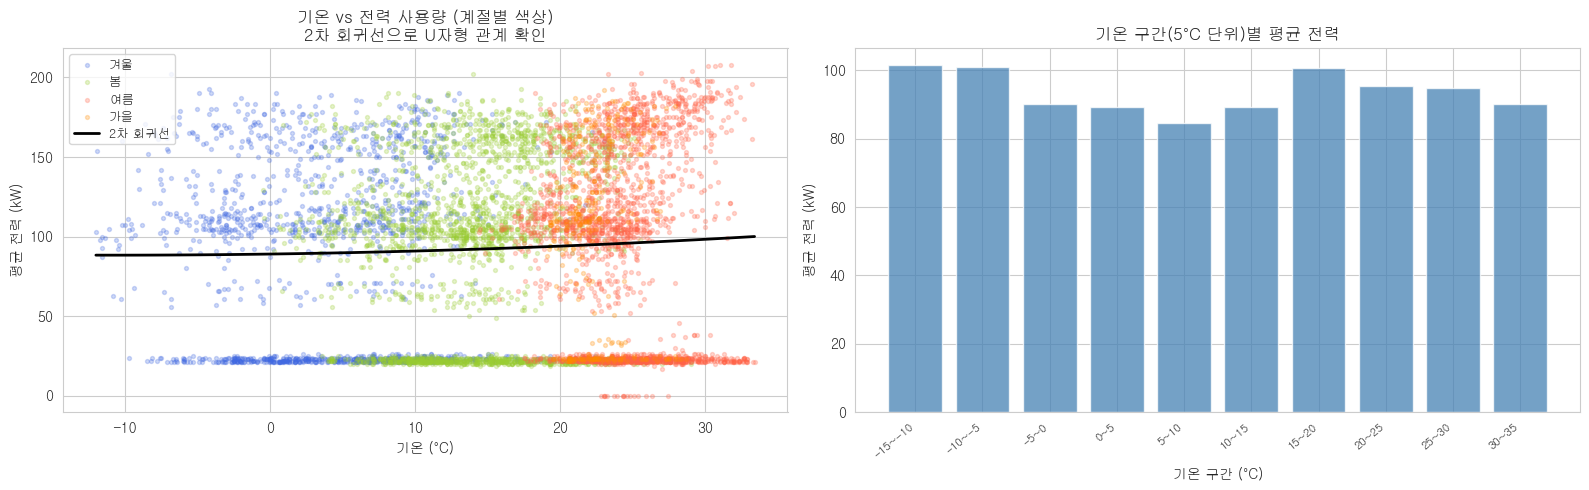

■ 인사이트
  - 기온이 낮을수록(겨울) 또는 높을수록(여름) 전력이 올라가는 U자형 경향
  - 선형 상관계수만으로는 이 관계를 잡지 못함
  - 모델 피처로 "기온" 외에 "기온^2 (기온의 제곱)"도 추가 필요
  - 또는 비선형 모델(XGBoost, LightGBM)을 사용하면 자동으로 처리 가능


In [169]:
# ============================================================
# 기온 vs 전력 비선형 관계 분석
# ------------------------------------------------------------
# 단순 상관계수는 "직선 관계"만 측정합니다.
# 하지만 기온과 전력은 U자형 관계일 수 있습니다:
#   - 여름(고온) → 냉방 부하 증가 → 전력 급증
#   - 겨울(저온) → 난방 부하 증가 → 전력 증가
#   - 봄/가을(적정 온도) → 전력 최저
# 이런 비선형 관계는 2차 회귀선으로 확인합니다.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── [왼쪽] 기온 vs 전력 산점도 (계절별 색상) ──────────────────
season_colors = {'겨울': 'royalblue', '봄': 'yellowgreen',
                 '여름': 'tomato',    '가을': 'darkorange'}

for season, color in season_colors.items():
    sub = df[df['계절'] == season]
    if len(sub) > 0:
        axes[0].scatter(sub['기온'], sub['평균'],
                        alpha=0.25, s=8, color=color, label=season)

# 2차 다항 회귀선 (U자형 곡선 확인용)
# np.polyfit(x, y, 2) = x와 y의 관계를 2차 방정식으로 피팅
valid = df[['기온','평균']].dropna()
z = np.polyfit(valid['기온'], valid['평균'], 2)
p = np.poly1d(z)
x_range = np.linspace(valid['기온'].min(), valid['기온'].max(), 100)
axes[0].plot(x_range, p(x_range), 'k-', linewidth=2, label='2차 회귀선')

axes[0].set_title('기온 vs 전력 사용량 (계절별 색상)\n2차 회귀선으로 U자형 관계 확인')
axes[0].set_xlabel('기온 (°C)')
axes[0].set_ylabel('평균 전력 (kW)')
axes[0].legend(fontsize=9)

# ── [오른쪽] 기온 구간별 평균 전력 막대그래프 ─────────────────
# 5°C 간격으로 묶어서 구간별 평균 전력을 비교
df['기온_구간'] = pd.cut(df['기온'],
                        bins=range(-15, 40, 5),
                        labels=[f'{i}~{i+5}' for i in range(-15, 35, 5)])

temp_power = df.groupby('기온_구간', observed=True)['평균'].mean()

axes[1].bar(range(len(temp_power)), temp_power.values,
            color='steelblue', alpha=0.75, edgecolor='white')
axes[1].set_xticks(range(len(temp_power)))
axes[1].set_xticklabels(temp_power.index, rotation=40, ha='right', fontsize=8)
axes[1].set_title('기온 구간(5°C 단위)별 평균 전력')
axes[1].set_ylabel('평균 전력 (kW)')
axes[1].set_xlabel('기온 구간 (°C)')

plt.tight_layout()
plt.show()

print('■ 인사이트')
print('  - 기온이 낮을수록(겨울) 또는 높을수록(여름) 전력이 올라가는 U자형 경향')
print('  - 선형 상관계수만으로는 이 관계를 잡지 못함')
print('  - 모델 피처로 "기온" 외에 "기온^2 (기온의 제곱)"도 추가 필요')
print('  - 또는 비선형 모델(XGBoost, LightGBM)을 사용하면 자동으로 처리 가능')

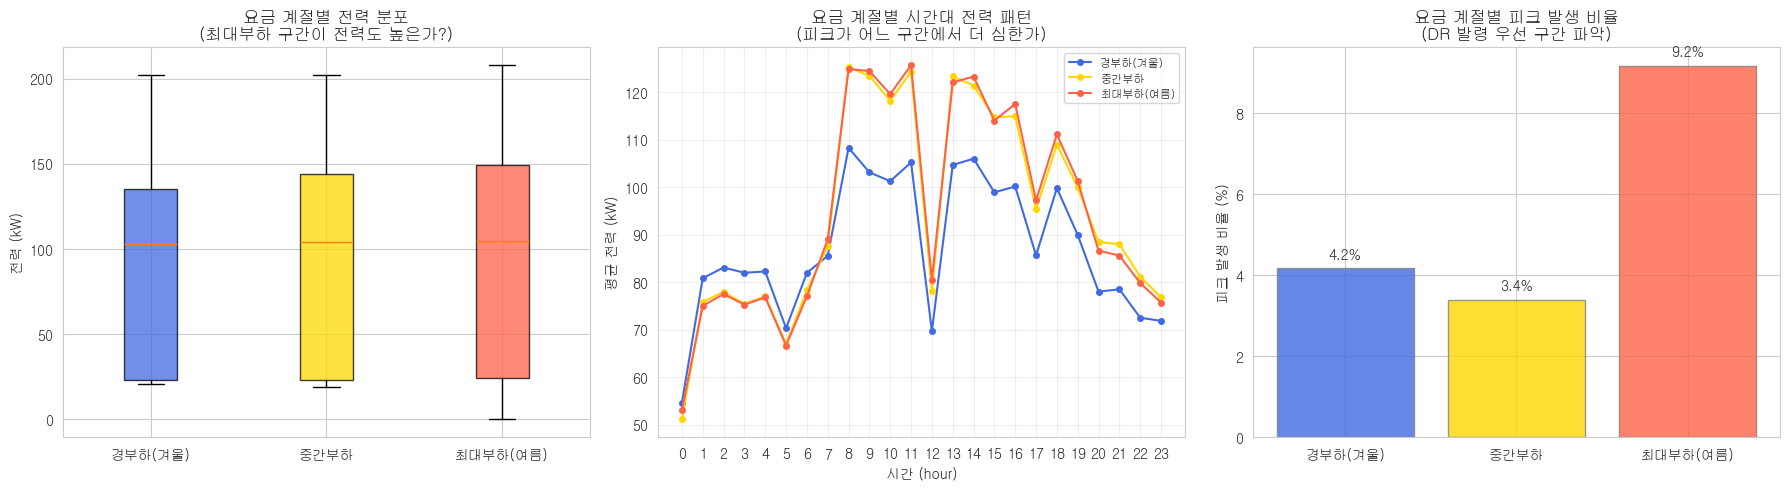

■ 요금 계절별 요약
  경부하(겨울) (109.8원/kWh): 1416시간, 평균전력 87.3kW, 피크비율 4.2%
  중간부하 (167.2원/kWh): 2544시간, 평균전력 94.7kW, 피크비율 3.4%
  최대부하(여름) (191.6원/kWh): 2160시간, 평균전력 95.0kW, 피크비율 9.2%

  ※ 피크비율이 높고 단가도 높은 구간 = DR 프로그램 최우선 적용 대상


In [170]:
# ============================================================
# 전기요금 계절별 전력 패턴 분석
# ------------------------------------------------------------
# 한전 전기요금은 계절에 따라 3가지 단가로 구분됩니다:
#   - 경부하 (109.8원/kWh): 주로 겨울철 — 전력 수요가 낮은 시기
#   - 중간부하 (167.2원/kWh): 봄/가을 — 중간 수요 시기
#   - 최대부하 (191.6원/kWh): 여름철 — 전력 수요가 가장 높은 시기
#
# 요금 단가가 높은 구간에서 피크가 발생하면 요금 폭탄이 됩니다!
# → DR(수요반응) 프로그램도 이 구간에서 주로 발령됩니다.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tariff_order  = ['경부하(겨울)', '중간부하', '최대부하(여름)']
tariff_colors = ['royalblue', 'gold', 'tomato']

# ── [왼쪽] 요금 구간별 전력 분포 (박스플롯) ──────────────────
tariff_data = [df[df['요금_계절'] == t]['평균'].values for t in tariff_order]
bp = axes[0].boxplot(tariff_data, labels=tariff_order, patch_artist=True)
for patch, color in zip(bp['boxes'], tariff_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_title('요금 계절별 전력 분포\n(최대부하 구간이 전력도 높은가?)')
axes[0].set_ylabel('전력 (kW)')

# ── [가운데] 요금 구간별 시간대 패턴 ─────────────────────────
for tariff, color in zip(tariff_order, tariff_colors):
    sub = df[df['요금_계절'] == tariff].groupby('시간')['평균'].mean()
    axes[1].plot(sub.index, sub.values, 'o-',
                 markersize=4, linewidth=1.5,
                 label=tariff, color=color)
axes[1].set_title('요금 계절별 시간대 전력 패턴\n(피크가 어느 구간에서 더 심한가)')
axes[1].set_xlabel('시간 (hour)')
axes[1].set_ylabel('평균 전력 (kW)')
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ── [오른쪽] 요금 구간별 피크 발생 비율 ──────────────────────
peak_rate = (df.groupby('요금_계절')['is_peak']
               .mean()
               .reindex(tariff_order) * 100)
bars = axes[2].bar(tariff_order, peak_rate.values,
                   color=tariff_colors, alpha=0.8, edgecolor='gray')
# 막대 위에 수치 표시
for bar, val in zip(bars, peak_rate.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('요금 계절별 피크 발생 비율\n(DR 발령 우선 구간 파악)')
axes[2].set_ylabel('피크 발생 비율 (%)')

plt.tight_layout()
plt.show()

print('■ 요금 계절별 요약')
for t, color in zip(tariff_order, ['109.8', '167.2', '191.6']):
    sub   = df[df['요금_계절'] == t]
    n     = len(sub)
    pmean = sub['평균'].mean()
    prate = sub['is_peak'].mean() * 100
    print(f'  {t} ({color}원/kWh): {n}시간, 평균전력 {pmean:.1f}kW, 피크비율 {prate:.1f}%')
print()
print('  ※ 피크비율이 높고 단가도 높은 구간 = DR 프로그램 최우선 적용 대상')

---
## 7. 생산량 - 전력 관계 분석

> 제조 공장에서 전력 사용량은 **생산 활동**과 직결됩니다.  
> 생산량이 많을수록 전력이 올라가는지, 어떤 관계인지 파악합니다.  
> 이 관계가 명확할수록 → 생산 계획을 피처로 활용해 피크를 예측할 수 있습니다.

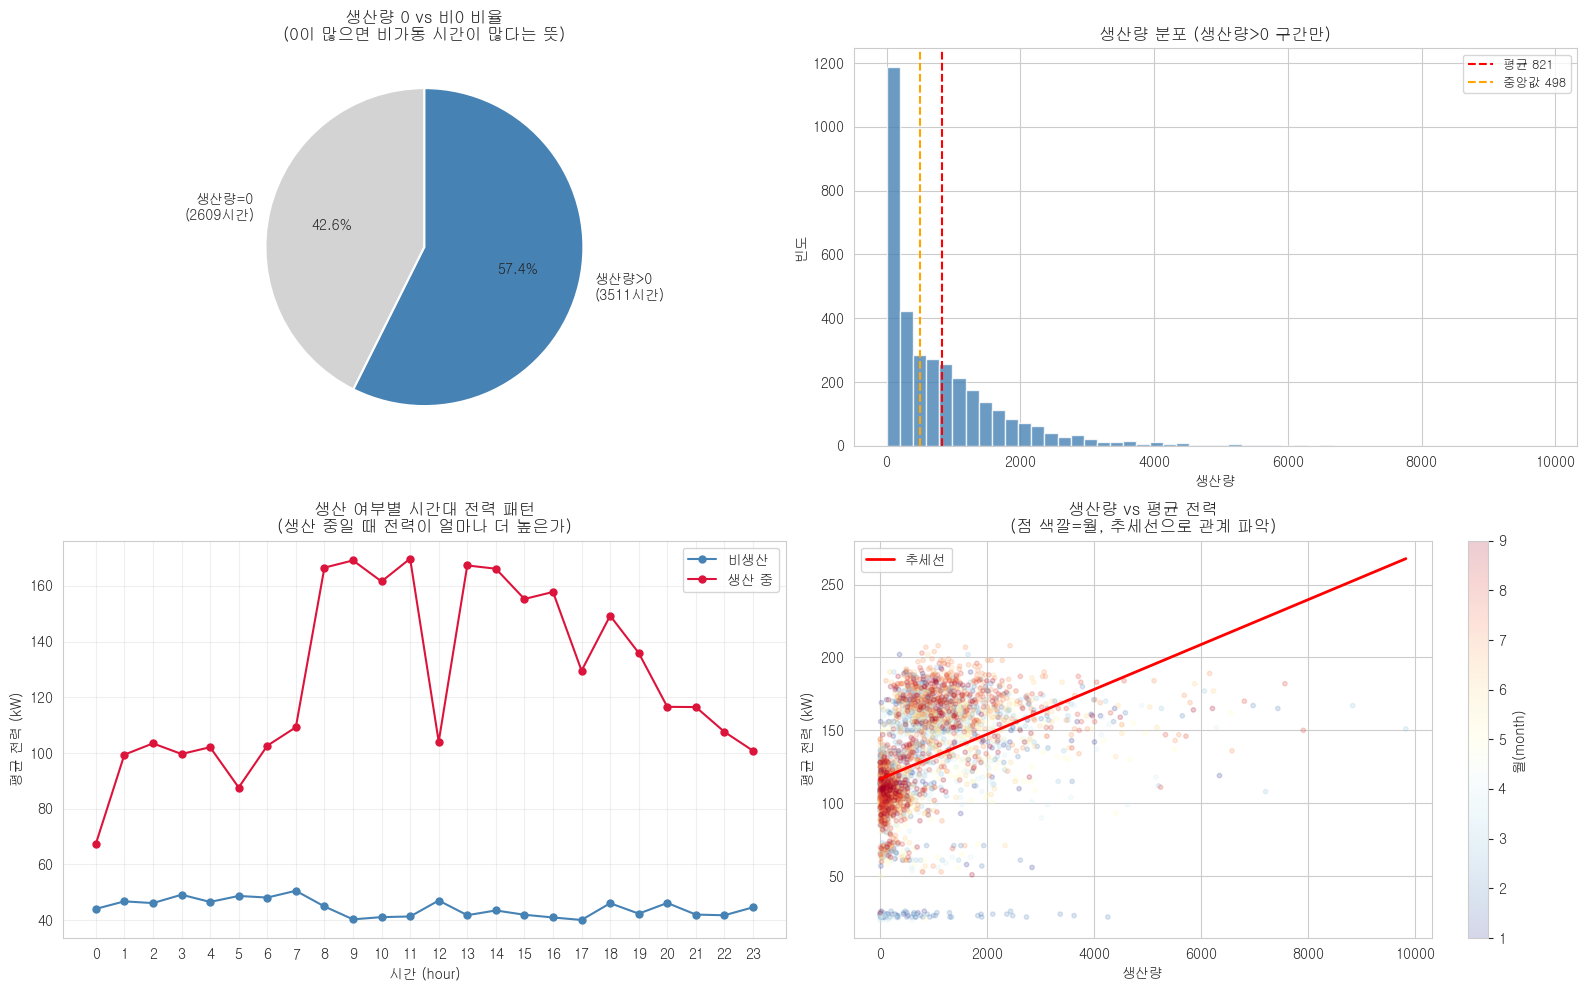

■ 생산량-전력 Pearson 상관계수: 0.524
  생산=0 평균 전력: 44.5 kW
  생산>0 평균 전력: 129.2 kW
  생산 시 전력 증가폭: +84.6 kW

  ※ 상관계수가 높을수록 → 생산량을 피처로 쓰면 피크 예측 정확도 향상


In [171]:
# ============================================================
# 생산량 기본 분포 및 전력과의 관계
# ------------------------------------------------------------
# 생산량=0 인 시간이 많은 이유:
#   - 야간/새벽 비가동 시간
#   - 주말 휴무
#   - 설비 유지보수 시간
# 생산량>0 인 시간의 전력 패턴을 따로 분석해야 합니다.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── [좌상] 생산량 0 vs 비0 비율 ───────────────────────────────
n_zero    = (df['생산량'] == 0).sum()
n_nonzero = (df['생산량'] >  0).sum()
axes[0,0].pie([n_zero, n_nonzero],
              labels=[f'생산량=0\n({n_zero}시간)', f'생산량>0\n({n_nonzero}시간)'],
              colors=['lightgray', 'steelblue'],
              autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0,0].set_title('생산량 0 vs 비0 비율\n(0이 많으면 비가동 시간이 많다는 뜻)')

# ── [우상] 생산량>0 구간의 분포 ───────────────────────────────
prod_nz = df[df['생산량'] > 0]['생산량']
axes[0,1].hist(prod_nz, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].axvline(prod_nz.mean(), color='red', linestyle='--',
                  linewidth=1.5, label=f'평균 {prod_nz.mean():.0f}')
axes[0,1].axvline(prod_nz.median(), color='orange', linestyle='--',
                  linewidth=1.5, label=f'중앙값 {prod_nz.median():.0f}')
axes[0,1].set_title('생산량 분포 (생산량>0 구간만)')
axes[0,1].set_xlabel('생산량')
axes[0,1].set_ylabel('빈도')
axes[0,1].legend(fontsize=9)

# ── [좌하] 생산 여부별 시간대 전력 패턴 ──────────────────────
# 생산 중일 때와 비생산 시간의 전력 패턴이 얼마나 다른지 비교
for flag, label, color in [(0,'비생산','steelblue'),(1,'생산 중','crimson')]:
    sub = df[df['생산량'] > 0] if flag else df[df['생산량'] == 0]
    h   = sub.groupby('시간')['평균'].mean()
    axes[1,0].plot(h.index, h.values, 'o-',
                   markersize=5, linewidth=1.5, label=label, color=color)
axes[1,0].set_title('생산 여부별 시간대 전력 패턴\n(생산 중일 때 전력이 얼마나 더 높은가)')
axes[1,0].set_xlabel('시간 (hour)')
axes[1,0].set_ylabel('평균 전력 (kW)')
axes[1,0].set_xticks(range(0,24))
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ── [우하] 생산량 vs 전력 산점도 ─────────────────────────────
# 산점도: 두 변수의 관계를 점으로 표현 (양의 관계면 오른쪽 위로 퍼짐)
df_prod = df[df['생산량'] > 0]
sc = axes[1,1].scatter(df_prod['생산량'], df_prod['평균'],
                       alpha=0.2, s=10,
                       c=df_prod['m'], cmap='RdYlBu_r')
plt.colorbar(sc, ax=axes[1,1], label='월(month)')

# 추세선 추가
z = np.polyfit(df_prod['생산량'], df_prod['평균'], 1)
p = np.poly1d(z)
x_r = np.linspace(df_prod['생산량'].min(), df_prod['생산량'].max(), 100)
axes[1,1].plot(x_r, p(x_r), 'r-', linewidth=2, label='추세선')
axes[1,1].set_title('생산량 vs 평균 전력\n(점 색깔=월, 추세선으로 관계 파악)')
axes[1,1].set_xlabel('생산량')
axes[1,1].set_ylabel('평균 전력 (kW)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

corr_val = df[['생산량','평균']].corr().iloc[0,1]
print(f'■ 생산량-전력 Pearson 상관계수: {corr_val:.3f}')
print(f'  생산=0 평균 전력: {df[df["생산량"]==0]["평균"].mean():.1f} kW')
print(f'  생산>0 평균 전력: {df[df["생산량"]>0]["평균"].mean():.1f} kW')
diff = df[df['생산량']>0]['평균'].mean() - df[df['생산량']==0]['평균'].mean()
print(f'  생산 시 전력 증가폭: +{diff:.1f} kW')
print()
print('  ※ 상관계수가 높을수록 → 생산량을 피처로 쓰면 피크 예측 정확도 향상')

---
## 8. 한전 DR (수요반응) 계산

> **DR(Demand Response, 수요반응)** 이란?  
> 전력 공급이 부족할 때 한전이 공장에게 "전력을 줄여달라"고 요청하는 제도입니다.  
> 공장이 요청대로 전력을 감축하면 → **감축량 × 단가 × 인센티브** 만큼 정산금을 받습니다.
>
> **CBL (Customer Baseline Load, 고객 기준부하)**  
> "DR이 없었다면 이 정도 썼을 것"이라는 기준값입니다.  
> 한전 표준: DR 발령일 이전 10개 평일 중 **상위 5일 평균** (MCP 방식)  
> **감축량** = CBL − DR 기간 실제 사용량  
> **정산금** ≈ 감축량(kWh) × 전기요금 단가 × 인센티브 배율(보통 1.5배)

In [172]:
# ============================================================
# CBL 계산 함수 정의
# ------------------------------------------------------------
# CBL = DR 발령일 이전 10개 평일 중 상위 5일의 평균 전력
# 즉, "최근 2주 동안 비슷한 날들 중 전력을 많이 쓴 상위 5일 평균"
# ============================================================

def calc_cbl(df_input, dr_date, dr_hours):
    """
    CBL 계산 및 DR 정산금 산출 함수

    Parameters
    ----------
    df_input : 전체 전력 데이터프레임
    dr_date  : DR 발령일 (int, YYYYMMDD 형식)
    dr_hours : DR 발령 시간대 리스트 (예: [14, 15, 16, 17])

    Returns
    -------
    dict : CBL, 감축량, 정산금 정보
    """
    dr_dt = pd.to_datetime(str(dr_date), format='%Y%m%d')

    # ── 이전 평일 10개 날짜 수집 ─────────────────────────────
    # 주말(토/일)을 제외하고 평일만 10개 찾습니다
    prev_workdays = []
    check = dr_dt - pd.Timedelta(days=1)
    while len(prev_workdays) < 10:
        if check.weekday() < 5:   # 0=월 ~ 4=금 → 평일
            d_int = int(check.strftime('%Y%m%d'))
            if d_int in df_input['날짜'].values:
                prev_workdays.append(d_int)
        check -= pd.Timedelta(days=1)

    if len(prev_workdays) < 5:
        return None   # 데이터 부족

    # ── 각 평일의 DR 시간대 평균 전력 계산 ───────────────────
    daily_powers = []
    for d in prev_workdays:
        sub = df_input[(df_input['날짜'] == d) & (df_input['시간'].isin(dr_hours))]
        if len(sub) > 0:
            daily_powers.append(sub['평균'].mean())

    if len(daily_powers) < 5:
        return None

    # ── CBL = 상위 5일 평균 (MCP 방식) ───────────────────────
    cbl = np.mean(sorted(daily_powers, reverse=True)[:5])

    # ── DR일 실제 사용량 ──────────────────────────────────────
    actual = df_input[
        (df_input['날짜'] == dr_date) & (df_input['시간'].isin(dr_hours))
    ]['평균'].mean()

    # ── 감축량 & 정산금 ───────────────────────────────────────
    # 감축량은 음수가 될 수 없음 (실제가 CBL보다 높으면 감축 실패 → 0)
    reduction = max(cbl - actual, 0)
    tariff    = df_input[df_input['날짜'] == dr_date]['전기요금(계절)'].iloc[0]
    incentive = 1.5   # 한전 인센티브 배율 (예시)
    payout    = reduction * len(dr_hours) * tariff * incentive

    return {
        'dr_date'    : dr_date,
        'cbl_kw'     : round(cbl, 2),
        'actual_kw'  : round(actual, 2),
        'reduction_kw': round(reduction, 2),
        'tariff'     : tariff,
        'payout_원'  : round(payout, 0)
    }

print('CBL 계산 함수 정의 완료')
print()
print('■ 계산 흐름 요약')
print('  1) DR 발령일 이전 평일 10일 수집')
print('  2) 각 날의 DR 시간대(예: 14~17시) 평균 전력 계산')
print('  3) 상위 5일 평균 → CBL')
print('  4) 감축량 = CBL - 당일 실제 사용량')
print('  5) 정산금 = 감축량 × 시간 수 × 요금 단가 × 1.5')

CBL 계산 함수 정의 완료

■ 계산 흐름 요약
  1) DR 발령일 이전 평일 10일 수집
  2) 각 날의 DR 시간대(예: 14~17시) 평균 전력 계산
  3) 상위 5일 평균 → CBL
  4) 감축량 = CBL - 당일 실제 사용량
  5) 정산금 = 감축량 × 시간 수 × 요금 단가 × 1.5


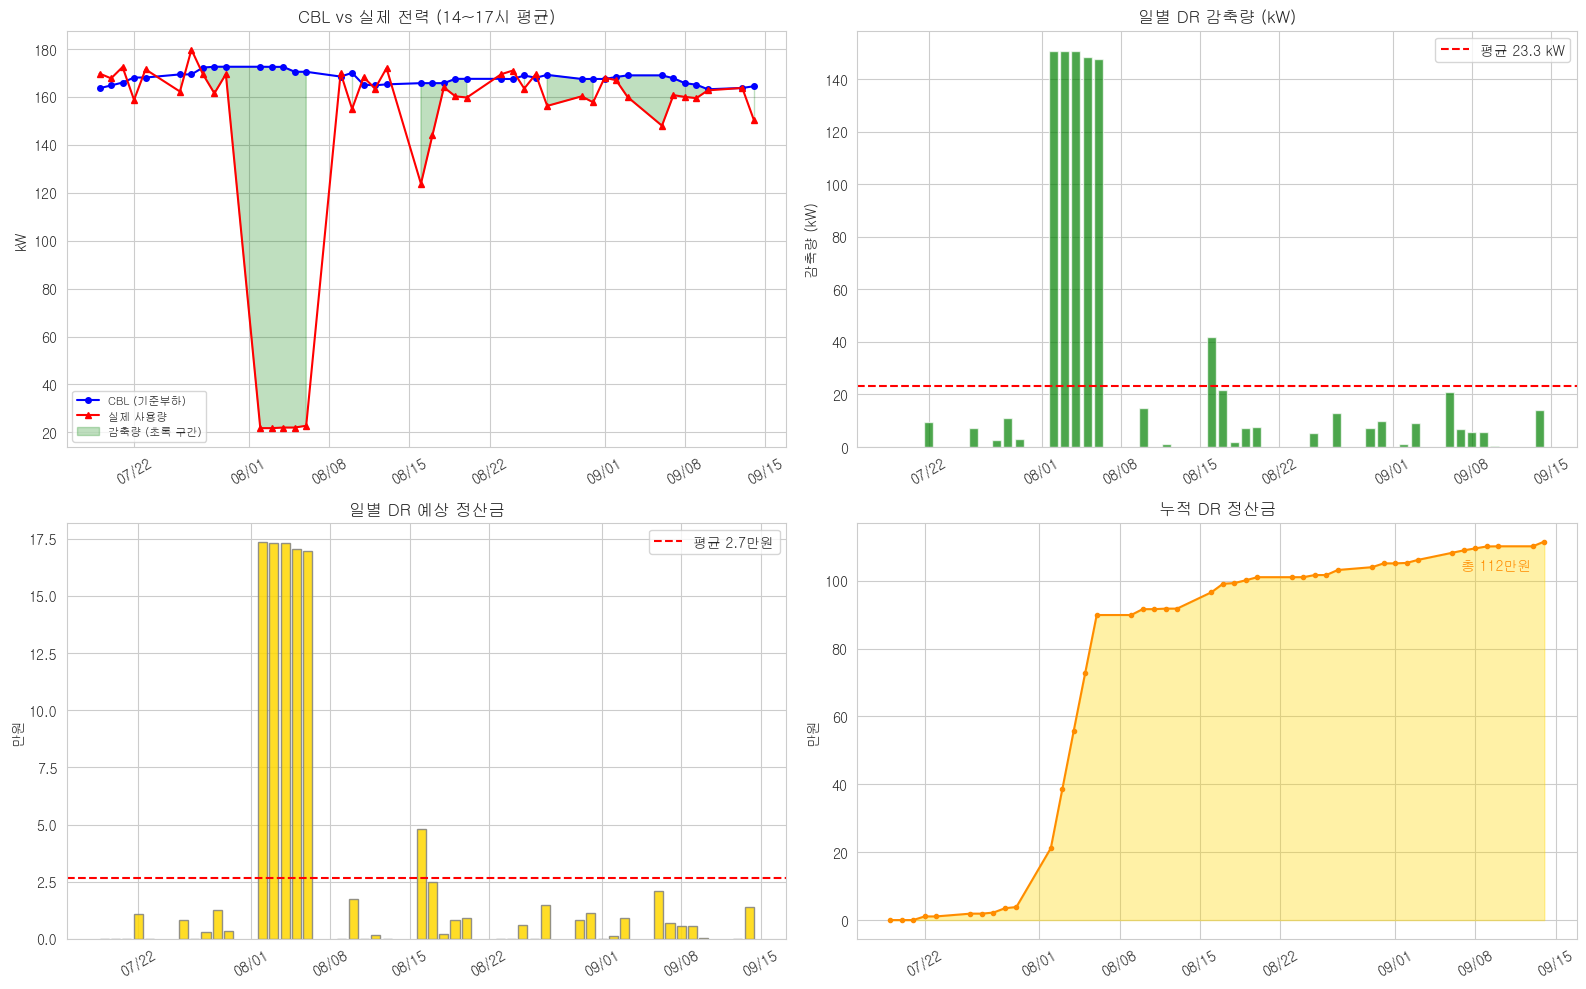

■ DR 시뮬레이션 결과 요약
  시뮬레이션 기간 : 2021-07-19 ~ 2021-09-14
  DR 발령 시간    : 14~18시 (4시간/일)
  총 DR 발령 일수 : 42일
  평균 CBL        : 167.9 kW
  평균 감축량     : 23.3 kW
  일 평균 정산금  : 2.7 만원
  총 예상 정산금  : 111.5 만원

  ※ 가정: 인센티브 배율 1.5배, 최대부하 요금 191.6원/kWh
  ※ 실제 DR 참여 시 계약 조건에 따라 달라질 수 있습니다


In [173]:
# ============================================================
# DR 시뮬레이션 — 여름 피크 시간대 전체 적용
# ------------------------------------------------------------
# 가정: 7~9월 평일, 오후 14~17시 (4시간) DR 발령
# → 각 날짜별 CBL, 실제 사용량, 감축량, 정산금 계산
# ============================================================

DR_HOURS = [14, 15, 16, 17]   # DR 발령 시간대

# 7~9월 평일만 추출 (앞 10일은 CBL 계산용으로 제외)
summer_workdays = sorted(
    df[(df['m'].isin([7,8,9])) & (df['is_workday']==1)]['날짜'].unique()
)[10:]

# 날짜별 DR 계산 실행
dr_results = []
for dr_date in summer_workdays:
    result = calc_cbl(df, dr_date, DR_HOURS)
    if result:
        dr_results.append(result)

dr_df = pd.DataFrame(dr_results)
dr_df['날짜_dt'] = pd.to_datetime(dr_df['dr_date'].astype(str), format='%Y%m%d')

# ── 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# [좌상] CBL vs 실제 사용량
ax = axes[0,0]
ax.plot(dr_df['날짜_dt'], dr_df['cbl_kw'],
        'b-o', markersize=4, linewidth=1.5, label='CBL (기준부하)')
ax.plot(dr_df['날짜_dt'], dr_df['actual_kw'],
        'r-^', markersize=4, linewidth=1.5, label='실제 사용량')
ax.fill_between(dr_df['날짜_dt'], dr_df['actual_kw'], dr_df['cbl_kw'],
                where=dr_df['cbl_kw'] > dr_df['actual_kw'],
                alpha=0.25, color='green', label='감축량 (초록 구간)')
ax.set_title('CBL vs 실제 전력 (14~17시 평균)')
ax.set_ylabel('kW')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax.tick_params(axis='x', rotation=30)

# [우상] 일별 감축량
ax2 = axes[0,1]
ax2.bar(dr_df['날짜_dt'], dr_df['reduction_kw'], color='green', alpha=0.7)
ax2.axhline(dr_df['reduction_kw'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'평균 {dr_df["reduction_kw"].mean():.1f} kW')
ax2.set_title('일별 DR 감축량 (kW)')
ax2.set_ylabel('감축량 (kW)')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax2.tick_params(axis='x', rotation=30)

# [좌하] 일별 정산금
ax3 = axes[1,0]
ax3.bar(dr_df['날짜_dt'], dr_df['payout_원']/10000,
        color='gold', alpha=0.85, edgecolor='gray')
ax3.axhline(dr_df['payout_원'].mean()/10000, color='red', linestyle='--',
            linewidth=1.5, label=f'평균 {dr_df["payout_원"].mean()/10000:.1f}만원')
ax3.set_title('일별 DR 예상 정산금')
ax3.set_ylabel('만원')
ax3.legend()
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax3.tick_params(axis='x', rotation=30)

# [우하] 누적 정산금
ax4 = axes[1,1]
cumsum = dr_df['payout_원'].cumsum()
ax4.fill_between(dr_df['날짜_dt'], cumsum/10000, alpha=0.35, color='gold')
ax4.plot(dr_df['날짜_dt'], cumsum/10000, 'o-', markersize=3, color='darkorange')
ax4.set_title('누적 DR 정산금')
ax4.set_ylabel('만원')
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax4.tick_params(axis='x', rotation=30)
# 최종 누적값 표시
ax4.annotate(f'총 {cumsum.iloc[-1]/10000:.0f}만원',
             xy=(dr_df['날짜_dt'].iloc[-1], cumsum.iloc[-1]/10000),
             xytext=(-60, -20), textcoords='offset points',
             fontsize=10, color='darkorange', fontweight='bold')

plt.tight_layout()
plt.show()

print('■ DR 시뮬레이션 결과 요약')
print(f'  시뮬레이션 기간 : {dr_df["날짜_dt"].min().date()} ~ {dr_df["날짜_dt"].max().date()}')
print(f'  DR 발령 시간    : {DR_HOURS[0]}~{DR_HOURS[-1]+1}시 ({len(DR_HOURS)}시간/일)')
print(f'  총 DR 발령 일수 : {len(dr_df)}일')
print(f'  평균 CBL        : {dr_df["cbl_kw"].mean():.1f} kW')
print(f'  평균 감축량     : {dr_df["reduction_kw"].mean():.1f} kW')
print(f'  일 평균 정산금  : {dr_df["payout_원"].mean()/10000:.1f} 만원')
print(f'  총 예상 정산금  : {dr_df["payout_원"].sum()/10000:.1f} 만원')
print()
print('  ※ 가정: 인센티브 배율 1.5배, 최대부하 요금 191.6원/kWh')
print('  ※ 실제 DR 참여 시 계약 조건에 따라 달라질 수 있습니다')

---
## 9. 피처 엔지니어링 방향

> **피처(Feature)** 란 모델이 학습할 때 입력으로 사용하는 변수들입니다.  
> 원본 데이터에 있는 컬럼 그대로 쓰는 것보다, **의미 있는 새 변수를 만들어 추가**하면 모델 성능이 크게 올라갑니다.  
> 피크 경보 모델에 필요한 피처들을 설계합니다.

In [174]:
# ============================================================
# 피처 엔지니어링
# ============================================================

df_feat = df.sort_values('datetime').copy()

# ── 1) 시간 주기 피처 ─────────────────────────────────────────
# 문제: 시간(0~23)을 그냥 숫자로 쓰면 모델이 "23시와 0시가 가깝다"는 걸 모릅니다.
# 해결: sin/cos 변환으로 시간을 원형(circular)으로 표현합니다.
#   → hour_sin, hour_cos 두 값이 함께 시간의 위치를 표현합니다.
df_feat['hour_sin']   = np.sin(2 * np.pi * df_feat['시간'] / 24)
df_feat['hour_cos']   = np.cos(2 * np.pi * df_feat['시간'] / 24)
df_feat['month_sin']  = np.sin(2 * np.pi * df_feat['m'] / 12)
df_feat['month_cos']  = np.cos(2 * np.pi * df_feat['m'] / 12)
df_feat['day_sin']    = np.sin(2 * np.pi * df_feat['day'] / 7)
df_feat['day_cos']    = np.cos(2 * np.pi * df_feat['day'] / 7)

# ── 2) 시간 범주 피처 ─────────────────────────────────────────
# "몇 시인지" 외에 "어떤 시간대인지"를 0/1로 표현
df_feat['is_peak_hour']  = df_feat['시간'].isin(range(9, 19)).astype(int)  # 업무시간
df_feat['is_summer']     = df_feat['m'].isin([7, 8, 9]).astype(int)
df_feat['is_winter']     = df_feat['m'].isin([12, 1, 2]).astype(int)
df_feat['is_lunch']      = df_feat['시간'].isin([12, 13]).astype(int)       # 점심시간

# ── 3) 라그(Lag) 피처 ────────────────────────────────────────
# "N시간 전 전력값"을 피처로 추가합니다.
# → 모델이 "지금 전력이 높으면 1시간 뒤도 높을 가능성"을 학습할 수 있습니다.
for lag in [1, 2, 3, 24, 48]:
    df_feat[f'avg_lag{lag}h'] = df_feat['평균'].shift(lag)

# ── 4) 롤링(Rolling) 통계 피처 ───────────────────────────────
# "최근 N시간 평균/표준편차"를 피처로 추가합니다.
# → 최근 추세가 올라가고 있는지, 변동이 크지 않은지 모델이 파악 가능
for window in [3, 6, 12, 24]:
    df_feat[f'roll_mean_{window}h'] = df_feat['평균'].shift(1).rolling(window).mean()
    df_feat[f'roll_std_{window}h']  = df_feat['평균'].shift(1).rolling(window).std()
df_feat['roll_max_24h'] = df_feat['평균'].shift(1).rolling(24).max()

# ── 5) 일별 누적 피처 ────────────────────────────────────────
# "오늘 하루 중 지금까지 최대 전력이 얼마였는지"
# → 이미 피크 근처까지 올라갔다면 → 피크 경보 발령 가능성 높음
df_feat['daily_max_sofar']  = df_feat.groupby('날짜')['평균'].transform(
    lambda x: x.shift(1).expanding().max()
)
df_feat['daily_mean_sofar'] = df_feat.groupby('날짜')['평균'].transform(
    lambda x: x.shift(1).expanding().mean()
)

# ── 6) 기상 파생 피처 ────────────────────────────────────────
# 불쾌지수: 기온+습도를 결합한 체감 더위 지표 → 냉방 부하와 연관
df_feat['불쾌지수'] = (0.81 * df_feat['기온']
                      + 0.01 * df_feat['습도'] * (0.99 * df_feat['기온'] - 14.99)
                      + 46.3)
df_feat['기온_제곱'] = df_feat['기온'] ** 2   # U자형 기온-전력 관계 반영

# ── 7) 전날/지난주 동일 시간 피처 ────────────────────────────
# "어제 이 시간에는 전력이 얼마였는지" → 요일 패턴 반영
df_feat['avg_yesterday_same_hour'] = df_feat.groupby('시간')['평균'].shift(1)
df_feat['avg_lastweek_same_hour']  = df_feat.groupby('시간')['평균'].shift(7)

# ── 8) 생산 관련 피처 ────────────────────────────────────────
df_feat['생산중']     = (df_feat['생산량'] > 0).astype(int)
df_feat['생산량_log'] = np.log1p(df_feat['생산량'])  # 로그 변환: 큰 값 압축

# ── 결과 확인 ─────────────────────────────────────────────────
new_features = [c for c in df_feat.columns if c not in df.columns]
print(f'■ 새로 생성된 피처 수: {len(new_features)}개')
print()
categories = {
    '시간 주기': ['hour_sin','hour_cos','month_sin','month_cos','day_sin','day_cos'],
    '시간 범주': ['is_peak_hour','is_summer','is_winter','is_lunch'],
    '라그 피처': [f'avg_lag{l}h' for l in [1,2,3,24,48]],
    '롤링 통계': [f'roll_mean_{w}h' for w in [3,6,12,24]] + ['roll_max_24h'],
    '일별 누적': ['daily_max_sofar','daily_mean_sofar'],
    '기상 파생': ['불쾌지수','기온_제곱'],
    '전날/지난주': ['avg_yesterday_same_hour','avg_lastweek_same_hour'],
    '생산 관련': ['생산중','생산량_log'],
}
for cat, feats in categories.items():
    print(f'  [{cat}]')
    for f in feats:
        print(f'    - {f}')

■ 새로 생성된 피처 수: 32개

  [시간 주기]
    - hour_sin
    - hour_cos
    - month_sin
    - month_cos
    - day_sin
    - day_cos
  [시간 범주]
    - is_peak_hour
    - is_summer
    - is_winter
    - is_lunch
  [라그 피처]
    - avg_lag1h
    - avg_lag2h
    - avg_lag3h
    - avg_lag24h
    - avg_lag48h
  [롤링 통계]
    - roll_mean_3h
    - roll_mean_6h
    - roll_mean_12h
    - roll_mean_24h
    - roll_max_24h
  [일별 누적]
    - daily_max_sofar
    - daily_mean_sofar
  [기상 파생]
    - 불쾌지수
    - 기온_제곱
  [전날/지난주]
    - avg_yesterday_same_hour
    - avg_lastweek_same_hour
  [생산 관련]
    - 생산중
    - 생산량_log


---
## 10. 데이터 증강 전략

> 현재 데이터: **2021년 1~9월, 약 255일, 6,120시간**  
>
> **증강이 필요한 이유 3가지**  
> 1. 피크가 전체의 **5%** → 클래스 불균형 심각 (모델이 "무조건 비피크"라 해도 95% 정확도)  
> 2. 10~12월 데이터 **없음** → 겨울철 전력 패턴을 모델이 학습 못함  
> 3. 전체 데이터 양이 **적음** → 복잡한 딥러닝 모델 학습에 부족

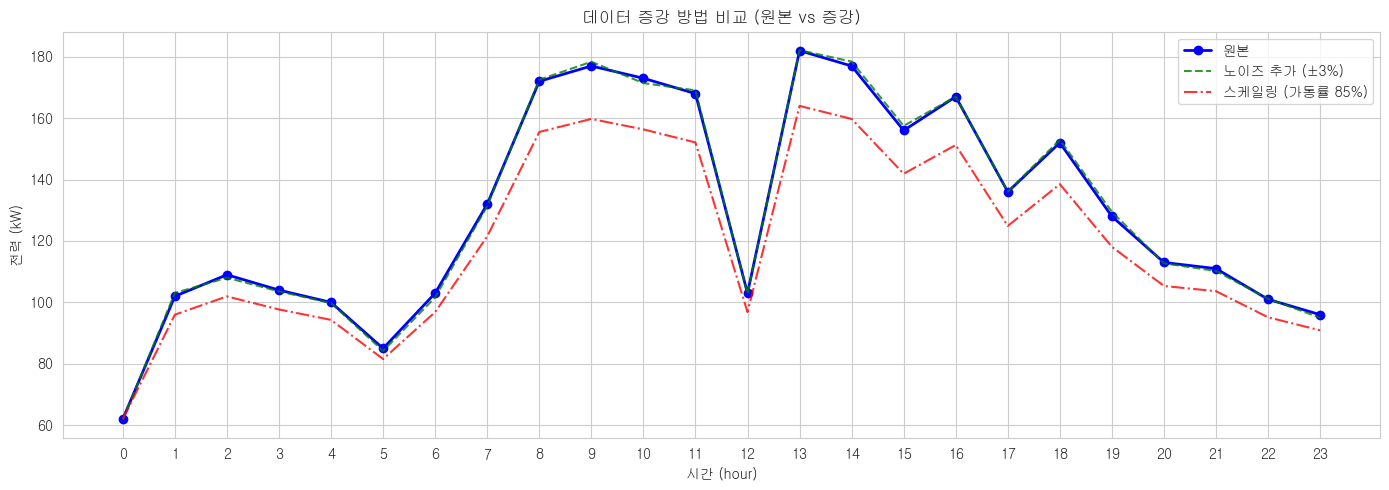

■ 권장 데이터 증강 전략

  [1단계] 피크 오버샘플링 (SMOTE)
    - 피크 시간대 행을 보간으로 합성
    - 목표: 피크 비율을 5% → 20~30% 수준으로 상향

  [2단계] 시계열 노이즈 증강
    - 매 날짜에 ±2~5% 노이즈 추가하여 유사 날 생성
    - 날짜 수 2~3배 확장 가능

  [3단계] 가동률 스케일링
    - 생산량 80~120% 시나리오로 다양한 부하 패턴 생성

  [4단계] 외부 데이터 확보 (가장 권장)
    - 2020년, 2022년 동일 공장 데이터 추가
    - 10~12월 겨울 데이터 확보 → 계절 편향 해소

  ⚠ 주의사항
    - 증강 데이터는 학습(Train)에만 사용, 검증(Val)/테스트(Test)에는 사용 금지
    - 시계열 분리 시 미래 데이터 누수(Data Leakage) 주의

  SMOTE 샘플 생성 예시: 300개 합성 피크 샘플 생성 가능


In [175]:
# ============================================================
# 데이터 증강 방법 시연 및 전략 정리
# ============================================================

sample_day = df[df['날짜'] == df['날짜'].unique()[60]].copy()

# ── 방법 1: 가우시안 노이즈 추가 ──────────────────────────────
# 원본 전력값에 아주 작은 랜덤 노이즈를 더해 유사한 날 생성
# → 같은 패턴이지만 조금씩 다른 날들을 만들어냄
def augment_noise(day_df, noise_ratio=0.03):
    aug = day_df.copy()
    for col in ['평균','15분','30분','45분','60분']:
        std   = day_df[col].std() * noise_ratio
        noise = np.random.normal(0, std, len(day_df))
        aug[col] = (day_df[col] + noise).clip(lower=0)
    return aug

# ── 방법 2: 스케일링 (가동률 변화 시뮬레이션) ─────────────────
# 생산량이 평소보다 적거나 많은 날을 시뮬레이션
# → 기저 부하(공장 항상 켜진 전력)는 유지, 가동 부하만 비율 조정
def augment_scale(day_df, scale=0.90):
    aug       = day_df.copy()
    base_load = day_df['평균'].min()   # 기저 부하
    for col in ['평균','15분','30분','45분','60분']:
        aug[col] = base_load + (day_df[col] - base_load) * scale
    return aug

# ── 방법 3: 피크 구간 SMOTE (오버샘플링) ──────────────────────
# 피크 발생 시간대 행들을 두 행씩 뽑아 중간값으로 새 샘플 생성
# → 피크 데이터를 인위적으로 늘려 클래스 불균형 해소
def augment_smote_peak(df_input, n=300):
    peaks = df_input[df_input['is_peak'] == 1].reset_index(drop=True)
    synth = []
    for _ in range(n):
        i1, i2 = np.random.choice(len(peaks), 2, replace=False)
        alpha  = np.random.uniform(0.3, 0.7)
        row    = peaks.iloc[i1].copy()
        for col in ['평균','15분','30분','45분','60분','기온','습도']:
            row[col] = alpha * peaks.iloc[i1][col] + (1-alpha) * peaks.iloc[i2][col]
        synth.append(row)
    return pd.DataFrame(synth)

# ── 시각화: 방법 1, 2 비교 ────────────────────────────────────
aug_noise = augment_noise(sample_day)
aug_scale = augment_scale(sample_day, scale=0.85)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_day['시간'], sample_day['평균'],
        'b-o', markersize=6, linewidth=2, label='원본')
ax.plot(aug_noise['시간'], aug_noise['평균'],
        'g--', linewidth=1.5, alpha=0.8, label='노이즈 추가 (±3%)')
ax.plot(aug_scale['시간'], aug_scale['평균'],
        'r-.', linewidth=1.5, alpha=0.8, label='스케일링 (가동률 85%)')
ax.set_title('데이터 증강 방법 비교 (원본 vs 증강)')
ax.set_xlabel('시간 (hour)')
ax.set_ylabel('전력 (kW)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

# ── 전략 요약 출력 ────────────────────────────────────────────
print('■ 권장 데이터 증강 전략')
print()
print('  [1단계] 피크 오버샘플링 (SMOTE)')
print('    - 피크 시간대 행을 보간으로 합성')
print('    - 목표: 피크 비율을 5% → 20~30% 수준으로 상향')
print()
print('  [2단계] 시계열 노이즈 증강')
print('    - 매 날짜에 ±2~5% 노이즈 추가하여 유사 날 생성')
print('    - 날짜 수 2~3배 확장 가능')
print()
print('  [3단계] 가동률 스케일링')
print('    - 생산량 80~120% 시나리오로 다양한 부하 패턴 생성')
print()
print('  [4단계] 외부 데이터 확보 (가장 권장)')
print('    - 2020년, 2022년 동일 공장 데이터 추가')
print('    - 10~12월 겨울 데이터 확보 → 계절 편향 해소')
print()
print('  ⚠ 주의사항')
print('    - 증강 데이터는 학습(Train)에만 사용, 검증(Val)/테스트(Test)에는 사용 금지')
print('    - 시계열 분리 시 미래 데이터 누수(Data Leakage) 주의')

n_synth = len(augment_smote_peak(df, n=300))
print(f'\n  SMOTE 샘플 생성 예시: {n_synth}개 합성 피크 샘플 생성 가능')

---
## EDA 최종 요약 및 다음 단계

### 핵심 인사이트

| 항목 | 내용 |
|------|------|
| 데이터 기간 | 2021.01~09 (255일, 6,120시간) |
| 피크 임계치 | 177 kW (95th percentile) |
| 피크 비율 | 약 5% → 심각한 클래스 불균형 |
| 주요 피크 시간 | 오전 10시 ~ 오후 17시 |
| 기온-전력 관계 | U자형 비선형 → 기온² 피처 필요 |
| 생산량-전력 상관 | 양의 상관 (생산↑ → 전력↑) |
| 한전 DR 잠재 수익 | 여름철(7~9월) 시뮬레이션 기준 계산 가능 |
| 누락 데이터 | 10~12월 없음 → 증강 필요 |

### 다음 단계 로드맵

1. **데이터 증강** → SMOTE + 노이즈 증강으로 피크 비율 조정
2. **피처 엔지니어링 완성** → 라그/롤링/주기 피처 포함 최종 데이터셋 저장
3. **피크 경보 모델 개발** → LightGBM / XGBoost / LSTM 비교 실험
4. **한전 DR 자동화 모듈** → CBL 실시간 계산 + 정산금 예측 API
5. **서비스 대시보드** → 실시간 피크 예측 + DR 정산 예상액 표시